In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.lines as mlines

In [3]:


def extract_metrics(content):

    patterns = {
        "Only_KNAPSACK_efficiency": r"Only KNAPSACK\s+efficiency:\s+([\d.]+)",
        "Final_Knapsack_time": r"Final Knapsack time:\s+([\d.e+-]+)",

        "Only_SFC_efficiency": r"Only SFC\s+efficiency:\s+([\d.]+)",
        "Final_SFC_time": r"Final SFC time:\s+([\d.e+-]+)",

        "SFC_painterPartition_efficiency": r"SFC\+painterPartition\s+efficiency:\s+([\d.]+)",
        "Final_SFC_Painter_time": r"Final SFC\+Painter time:\s+([\d.e+-]+)",

        "Painter_Knapsack_combined_efficiency": r"Painter\+Knapsack combined efficiency:\s+([\d.]+)",
        "Final_Painter_Knapsack_Combined_time": r"Final painter\+Knapsack_Combined time:\s+([\d.e+-]+)",

        "SFC_Knapsack_combined_efficiency": r"SFC\+Knapsack combined efficiency:\s+([\d.]+)",
        "Final_SFC_Knapsack_Combined_time": r"Final SFC\+Knapsack_Combined time:\s+([\d.e+-]+)",

        "Hilbert_SFC_efficiency": r"Hilbert SFC efficiency:\s+([\d.]+)",
        "Final_Hilbert_SFC_time": r"Final Hilbert SFC time:\s+([\d.e+-]+)",

        "Hilbert_painterPartition_efficiency": r"Hilbert\+painterPartition\s+efficiency:\s+([\d.]+)",
        "Final_Hilbert_Painter_time": r"Final Hilbert\+Painter time:\s+([\d.e+-]+)",
    }

    run_sections = re.split(r"=== Starting Run \d+ ===", content)[1:]  
    data = []

    for run_id, section in enumerate(run_sections, start=1):
        row = {"Run": run_id}
        for key, pattern in patterns.items():
            match = re.search(pattern, section)
            if match:
                row[key] = float(match.group(1))
            else:
                row[key] = None  
        data.append(row)
    
    return data


def consolidate_data_from_files(file_list):
    all_data = []
    
    for file_path in file_list:
        with open(file_path, 'r') as file:
            content = file.read()
        
        file_data = extract_metrics(content)
        for row in file_data:
            row["File"] = file_path
        all_data.extend(file_data)
    
    return pd.DataFrame(all_data)

file_paths = ['../output/run_250/4_4_output_best.txt', '../output/run_250/4_8_output_best.txt', '../output/run_250/4_16_output_best.txt',
              '../output/run_250/8_4_output_best.txt', '../output/run_250/8_8_output_best.txt', '../output/run_250/8_16_output_best.txt',
              '../output/run_250/16_4_output_best.txt', '../output/run_250/16_8_output_best.txt', '../output/run_250/16_16_output_best.txt',
              '../output/run_250/32_4_output_best.txt', '../output/run_250/32_8_output_best.txt', '../output/run_250/32_16_output_best.txt',
              '../output/run_250/64_4_output_best.txt', '../output/run_250/64_8_output_best.txt', '../output/run_250/64_16_output_best.txt',
              '../output/run_250/128_4_output_best.txt', '../output/run_250/128_8_output_best.txt', '../output/run_250/128_16_output_best.txt',
              '../output/run_250/256_4_output_best.txt', '../output/run_250/256_8_output_best.txt', '../output/run_250/256_16_output_best.txt',
              '../output/run_250/512_4_output_best.txt','../output/run_250/512_8_output_best.txt','../output/run_250/512_16_output_best.txt',
              '../output/run_250/1024_4_output_best.txt','../output/run_250/1024_8_output_best.txt','../output/run_250/1024_16_output_best.txt']



result_df = consolidate_data_from_files(file_paths)




In [4]:
result_df

,Run,Only_KNAPSACK_efficiency,Final_Knapsack_time,Only_SFC_efficiency,Final_SFC_time,SFC_painterPartition_efficiency,Final_SFC_Painter_time,Painter_Knapsack_combined_efficiency,Final_Painter_Knapsack_Combined_time,SFC_Knapsack_combined_efficiency,Final_SFC_Knapsack_Combined_time,Hilbert_SFC_efficiency,Final_Hilbert_SFC_time,Hilbert_painterPartition_efficiency,Final_Hilbert_Painter_time,File
0,1,0.999699,0.000086,0.800846,0.000073,0.998525,0.000055,0.999699,0.000060,0.999699,0.000053,1.000000,6.122866,0.999377,0.000041,../output/run_250/4_4_output_best.txt
1,2,0.999849,0.000063,0.800966,0.000060,0.999506,0.000031,0.999849,0.000047,0.999849,0.000041,1.000000,0.000268,0.999544,0.000028,../output/run_250/4_4_output_best.txt
2,3,0.999815,0.000060,0.998951,0.000055,0.998951,0.000050,0.999815,0.000067,0.999815,0.000058,1.000000,0.000371,0.999222,0.000035,../output/run_250/4_4_output_best.txt
3,4,0.999966,0.000087,0.800997,0.000083,0.998781,0.000037,0.999966,0.000065,0.999966,0.000056,1.000000,0.000374,0.998642,0.000035,../output/run_250/4_4_output_best.txt
4,5,0.999647,0.000088,0.800558,0.000081,0.997998,0.000035,0.999647,0.000067,0.999647,0.000060,1.000000,0.000361,0.999165,0.000041,../output/run_250/4_4_output_best.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,1,0.999953,0.013898,0.941356,0.007040,0.998175,0.061009,0.999279,0.847626,0.941592,0.006675,0.984777,6.460539,0.998147,0.836413,../output/run_250/1024_16_output_best.txt
131,2,0.999950,0.013812,0.941246,0.011109,0.997694,0.052141,0.999147,0.055332,0.941615,0.005438,0.984812,0.053909,0.998100,0.932328,../output/run_250/1024_16_output_best.txt
132,3,0.999952,0.013521,0.941348,0.009345,0.998095,0.895956,0.999016,0.838532,0.941463,0.005261,0.984638,0.075631,0.998102,0.811860,../output/run_250/1024_16_output_best.txt
133,4,0.999953,0.013320,0.941188,0.007023,0.998206,0.054758,0.999132,0.055852,0.941385,0.005233,0.984729,0.016205,0.998018,0.060281,../output/run_250/1024_16_output_best.txt


In [5]:
result_df.head(10)

,Run,Only_KNAPSACK_efficiency,Final_Knapsack_time,Only_SFC_efficiency,Final_SFC_time,SFC_painterPartition_efficiency,Final_SFC_Painter_time,Painter_Knapsack_combined_efficiency,Final_Painter_Knapsack_Combined_time,SFC_Knapsack_combined_efficiency,Final_SFC_Knapsack_Combined_time,Hilbert_SFC_efficiency,Final_Hilbert_SFC_time,Hilbert_painterPartition_efficiency,Final_Hilbert_Painter_time,File
0,1,0.999699,0.000086,0.800846,0.000073,0.998525,0.000055,0.999699,0.000060,0.999699,0.000053,1.0,6.122866,0.999377,0.000041,../output/run_250/4_4_output_best.txt
1,2,0.999849,0.000063,0.800966,0.000060,0.999506,0.000031,0.999849,0.000047,0.999849,0.000041,1.0,0.000268,0.999544,0.000028,../output/run_250/4_4_output_best.txt
2,3,0.999815,0.000060,0.998951,0.000055,0.998951,0.000050,0.999815,0.000067,0.999815,0.000058,1.0,0.000371,0.999222,0.000035,../output/run_250/4_4_output_best.txt
3,4,0.999966,0.000087,0.800997,0.000083,0.998781,0.000037,0.999966,0.000065,0.999966,0.000056,1.0,0.000374,0.998642,0.000035,../output/run_250/4_4_output_best.txt
4,5,0.999647,0.000088,0.800558,0.000081,0.997998,0.000035,0.999647,0.000067,0.999647,0.000060,1.0,0.000361,0.999165,0.000041,../output/run_250/4_4_output_best.txt
5,1,0.999905,0.000090,0.999598,0.000081,0.999598,0.000098,0.999905,0.000064,0.999905,0.000057,1.0,6.564056,0.998939,0.000272,../output/run_250/4_8_output_best.txt
6,2,0.999845,0.000066,0.889341,0.000065,0.999837,0.000032,0.999845,0.000065,0.999845,0.000044,1.0,0.000381,0.998949,0.000045,../output/run_250/4_8_output_best.txt
7,3,0.999961,0.000062,0.889281,0.000060,0.998971,0.000023,0.999961,0.000049,0.999961,0.000041,1.0,0.000295,0.999596,0.000031,../output/run_250/4_8_output_best.txt
8,4,0.999925,0.000065,0.888796,0.000061,0.999217,0.000026,0.999925,0.000050,0.999925,0.000043,1.0,0.000295,0.999399,0.000032,../output/run_250/4_8_output_best.txt
9,5,0.999882,0.000063,0.890323,0.000059,0.998564,0.000024,0.999882,0.000048,0.999882,0.000041,1.0,0.000281,0.998929,0.000029,../output/run_250/4_8_output_best.txt


In [6]:
result_df['File'] = result_df['File'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

In [7]:
result_df['File'] = result_df['File'].apply(lambda x: '_'.join([word.capitalize() for word in x.split('_')]))

In [8]:
result_df

,Run,Only_KNAPSACK_efficiency,Final_Knapsack_time,Only_SFC_efficiency,Final_SFC_time,SFC_painterPartition_efficiency,Final_SFC_Painter_time,Painter_Knapsack_combined_efficiency,Final_Painter_Knapsack_Combined_time,SFC_Knapsack_combined_efficiency,Final_SFC_Knapsack_Combined_time,Hilbert_SFC_efficiency,Final_Hilbert_SFC_time,Hilbert_painterPartition_efficiency,Final_Hilbert_Painter_time,File
0,1,0.999699,0.000086,0.800846,0.000073,0.998525,0.000055,0.999699,0.000060,0.999699,0.000053,1.000000,6.122866,0.999377,0.000041,4_4_Output_Best
1,2,0.999849,0.000063,0.800966,0.000060,0.999506,0.000031,0.999849,0.000047,0.999849,0.000041,1.000000,0.000268,0.999544,0.000028,4_4_Output_Best
2,3,0.999815,0.000060,0.998951,0.000055,0.998951,0.000050,0.999815,0.000067,0.999815,0.000058,1.000000,0.000371,0.999222,0.000035,4_4_Output_Best
3,4,0.999966,0.000087,0.800997,0.000083,0.998781,0.000037,0.999966,0.000065,0.999966,0.000056,1.000000,0.000374,0.998642,0.000035,4_4_Output_Best
4,5,0.999647,0.000088,0.800558,0.000081,0.997998,0.000035,0.999647,0.000067,0.999647,0.000060,1.000000,0.000361,0.999165,0.000041,4_4_Output_Best
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,1,0.999953,0.013898,0.941356,0.007040,0.998175,0.061009,0.999279,0.847626,0.941592,0.006675,0.984777,6.460539,0.998147,0.836413,1024_16_Output_Best
131,2,0.999950,0.013812,0.941246,0.011109,0.997694,0.052141,0.999147,0.055332,0.941615,0.005438,0.984812,0.053909,0.998100,0.932328,1024_16_Output_Best
132,3,0.999952,0.013521,0.941348,0.009345,0.998095,0.895956,0.999016,0.838532,0.941463,0.005261,0.984638,0.075631,0.998102,0.811860,1024_16_Output_Best
133,4,0.999953,0.013320,0.941188,0.007023,0.998206,0.054758,0.999132,0.055852,0.941385,0.005233,0.984729,0.016205,0.998018,0.060281,1024_16_Output_Best


In [9]:
result_df = result_df.rename(columns={'Only_KNAPSACK_efficiency': 'Only_Knapsack_Efficiency', 'Final_Knapsack_time': 'Only_Knapsack_Final_Time', 'Only_SFC_efficiency':'Only_SFC_Efficiency','Final_SFC_time': 'Only_SFC_Final_Time','SFC_painterPartition_efficiency': 'SFC_PainterPartition_Efficiency','Final_SFC_Painter_time': 'SFC_PainterPartition_Final_Time','Painter_Knapsack_combined_efficiency':'Painter_Knapsack_Combined_Efficiency','Final_Painter_Knapsack_Combined_time':'Painter_Knapsack_Combined_Final_Time','SFC_Knapsack_combined_efficiency':'SFC_Knapsack_Combined_Efficiency','Final_SFC_Knapsack_Combined_time':'SFC_Knapsack_Combined_Final_Time', 'Hilbert_SFC_efficiency':'Hilbert_SFC_Efficiency', 'Final_Hilbert_SFC_time':'Hilbert_SFC_Final_Time', 'Hilbert_painterPartition_efficiency':'Hilbert_PainterPartition_Efficiency', 'Final_Hilbert_Painter_time':'Hilbert_PainterPartition_Final_Time'} )

In [10]:
result_df

,Run,Only_Knapsack_Efficiency,Only_Knapsack_Final_Time,Only_SFC_Efficiency,Only_SFC_Final_Time,SFC_PainterPartition_Efficiency,SFC_PainterPartition_Final_Time,Painter_Knapsack_Combined_Efficiency,Painter_Knapsack_Combined_Final_Time,SFC_Knapsack_Combined_Efficiency,SFC_Knapsack_Combined_Final_Time,Hilbert_SFC_Efficiency,Hilbert_SFC_Final_Time,Hilbert_PainterPartition_Efficiency,Hilbert_PainterPartition_Final_Time,File
0,1,0.999699,0.000086,0.800846,0.000073,0.998525,0.000055,0.999699,0.000060,0.999699,0.000053,1.000000,6.122866,0.999377,0.000041,4_4_Output_Best
1,2,0.999849,0.000063,0.800966,0.000060,0.999506,0.000031,0.999849,0.000047,0.999849,0.000041,1.000000,0.000268,0.999544,0.000028,4_4_Output_Best
2,3,0.999815,0.000060,0.998951,0.000055,0.998951,0.000050,0.999815,0.000067,0.999815,0.000058,1.000000,0.000371,0.999222,0.000035,4_4_Output_Best
3,4,0.999966,0.000087,0.800997,0.000083,0.998781,0.000037,0.999966,0.000065,0.999966,0.000056,1.000000,0.000374,0.998642,0.000035,4_4_Output_Best
4,5,0.999647,0.000088,0.800558,0.000081,0.997998,0.000035,0.999647,0.000067,0.999647,0.000060,1.000000,0.000361,0.999165,0.000041,4_4_Output_Best
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,1,0.999953,0.013898,0.941356,0.007040,0.998175,0.061009,0.999279,0.847626,0.941592,0.006675,0.984777,6.460539,0.998147,0.836413,1024_16_Output_Best
131,2,0.999950,0.013812,0.941246,0.011109,0.997694,0.052141,0.999147,0.055332,0.941615,0.005438,0.984812,0.053909,0.998100,0.932328,1024_16_Output_Best
132,3,0.999952,0.013521,0.941348,0.009345,0.998095,0.895956,0.999016,0.838532,0.941463,0.005261,0.984638,0.075631,0.998102,0.811860,1024_16_Output_Best
133,4,0.999953,0.013320,0.941188,0.007023,0.998206,0.054758,0.999132,0.055852,0.941385,0.005233,0.984729,0.016205,0.998018,0.060281,1024_16_Output_Best


In [11]:
column_list = result_df['SFC_Knapsack_Combined_Efficiency'].tolist()

In [12]:
print(column_list)

[0.9996985207, 0.9998494586, 0.9998145386, 0.9999656384, 0.9996470618, 0.9999047086, 0.9998445125, 0.9999605753, 0.9999250036, 0.9998817369, 0.9999916265, 0.9999669066, 0.999978719, 0.9999429855, 0.9999112423, 0.9997595104, 0.9997242928, 0.8026010105, 0.999435348, 0.8023343533, 0.889677417, 0.9996877887, 0.9995693165, 0.9998377177, 0.999649055, 0.9416677787, 0.9998830453, 0.9997236681, 0.9998473813, 0.9417093842, 0.8029071028, 0.9994923282, 0.9988101701, 0.802164877, 0.9992296281, 0.8897492348, 0.889346113, 0.999570087, 0.8894595338, 0.8897552807, 0.94205754, 0.9994096888, 0.9414370251, 0.9998573115, 0.9418162685, 0.8027563631, 0.8019299497, 0.999018449, 0.8020517684, 0.8023265431, 0.8899257546, 0.9992071173, 0.8896644305, 0.8892951963, 0.889988836, 0.9414823153, 0.9417259107, 0.9416609247, 0.9414695033, 0.9417589777, 0.8021508266, 0.8020725559, 0.8020419711, 0.80213361, 0.8028835361, 0.8893498629, 0.889617882, 0.8897068097, 0.889501386, 0.8902039518, 0.941483647, 0.9418195047, 0.94153

In [13]:
# output_file = "./result/data.xlsx"

# with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
#     for file_name, group in result_df.groupby('File', sort=False):
#         sheet_name = file_name.split("/")[-1].replace(".txt", "")
#         group.to_excel(writer, sheet_name=sheet_name, index=False)


In [14]:
filename = '512_4_Output_Best'
df_1 = result_df[result_df['File'] == filename]

In [15]:
df_1

,Run,Only_Knapsack_Efficiency,Only_Knapsack_Final_Time,Only_SFC_Efficiency,Only_SFC_Final_Time,SFC_PainterPartition_Efficiency,SFC_PainterPartition_Final_Time,Painter_Knapsack_Combined_Efficiency,Painter_Knapsack_Combined_Final_Time,SFC_Knapsack_Combined_Efficiency,SFC_Knapsack_Combined_Final_Time,Hilbert_SFC_Efficiency,Hilbert_SFC_Final_Time,Hilbert_PainterPartition_Efficiency,Hilbert_PainterPartition_Final_Time,File
105,1,0.999716,0.006107,0.800272,0.003143,0.996745,0.007694,0.997581,0.014568,0.802119,0.001864,0.941417,6.273239,0.996336,0.010006,512_4_Output_Best
106,2,0.999725,0.005887,0.800097,0.003023,0.996086,0.001257,0.997981,0.002440,0.801660,0.001855,0.941505,0.003315,0.994898,0.001349,512_4_Output_Best
107,3,0.999716,0.005860,0.800335,0.003055,0.996467,0.014919,0.998434,0.014297,0.802736,0.001857,0.941343,0.002487,0.996643,0.001207,512_4_Output_Best
108,4,0.999738,0.005872,0.800224,0.003070,0.996590,0.001097,0.998060,0.002639,0.801834,0.001846,0.941316,0.002840,0.996602,0.001391,512_4_Output_Best
109,5,0.999681,0.006124,0.800376,0.003018,0.996843,0.001282,0.997447,0.014262,0.803074,0.001831,0.941421,0.002943,0.996389,0.001214,512_4_Output_Best


In [16]:
pd.set_option('display.max_columns', None)

In [17]:
# algorithms = [
#     ('Only_Knapsack', 'Only_Knapsack_Efficiency', 'Only_Knapsack_Final_Time'),
#     ('Only_SFC', 'Only_SFC_Efficiency', 'Only_SFC_Final_Time'),
#     ('SFC_PainterPartition', 'SFC_PainterPartition_Efficiency', 'SFC_PainterPartition_Final_Time'),
#     ('SFC_Knapsack_Combined', 'SFC_Knapsack_Combined_Efficiency', 'SFC_Knapsack_Combined_Final_Time')
# ]

# file_order = result_df['File'].drop_duplicates().tolist()
# result_df['File'] = pd.Categorical(result_df['File'], categories=file_order, ordered=True)

# grouped = result_df.groupby('File', sort=False)

# for file_name, group in grouped:
#     group = group.sort_values('Run')

#     fig, ax = plt.subplots(figsize=(20, 10))
#     ax.set_title(f'Efficiency Variation over Runs for Output Test Case: {file_name}', fontsize=20)
#     ax.set_xlabel('Run', fontsize=20)
#     ax.set_ylabel('Efficiency', fontsize=20)
#     plt.xticks(fontsize=16)
#     plt.yticks(fontsize=16)

#     for alg_name, eff_col, _ in algorithms:
#         ax.plot(group['Run'], group[eff_col], label=alg_name, marker='o', linestyle='-', linewidth=1, markersize=4)

#     ax.legend(title='Algorithms', title_fontsize=20, fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
#     ax.grid(True)
#     plt.tight_layout()
#     efficiency_filename = f'./result/all_run_data/{file_name}_efficiency.png'
#     plt.savefig(efficiency_filename, dpi=600)
#     plt.show()
#     fig, ax = plt.subplots(figsize=(20, 10))
#     ax.set_title(f'Time Variation over Runs for Output Test Case: {file_name}', fontsize=20)
#     ax.set_xlabel('Run', fontsize=20)
#     ax.set_ylabel('Time (seconds)', fontsize=20)
#     plt.xticks(fontsize=16)
#     plt.yticks(fontsize=16)

#     for alg_name, _, time_col in algorithms:
#         ax.plot(group['Run'], group[time_col], label=alg_name, marker='o', linestyle='-', linewidth=1, markersize=4)

#     ax.legend(title='Algorithms', title_fontsize=20, fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
#     ax.grid(True)
#     plt.tight_layout()
#     time_filename = f'./result/all_run_data/{file_name}_time.png'
#     plt.savefig(time_filename, dpi=600)
#     plt.show()


In [18]:
file_order = result_df['File'].drop_duplicates().tolist()
result_df['File'] = pd.Categorical(result_df['File'], categories=file_order, ordered=True)

grouped = result_df.groupby('File', sort=False)


/tmp/ipykernel_256607/3567121358.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = result_df.groupby('File', sort=False)


In [19]:
specific_group = grouped.get_group('512_8_Output_Best')
specific_group

,Run,Only_Knapsack_Efficiency,Only_Knapsack_Final_Time,Only_SFC_Efficiency,Only_SFC_Final_Time,SFC_PainterPartition_Efficiency,SFC_PainterPartition_Final_Time,Painter_Knapsack_Combined_Efficiency,Painter_Knapsack_Combined_Final_Time,SFC_Knapsack_Combined_Efficiency,SFC_Knapsack_Combined_Final_Time,Hilbert_SFC_Efficiency,Hilbert_SFC_Final_Time,Hilbert_PainterPartition_Efficiency,Hilbert_PainterPartition_Final_Time,File
110,1,0.999888,0.009115,0.888964,0.006821,0.997547,0.004552,0.998793,0.050388,0.889527,0.002131,0.969824,6.241872,0.997283,0.041940,512_8_Output_Best
111,2,0.999889,0.005964,0.889087,0.003160,0.997705,0.056083,0.998746,0.005894,0.889619,0.002096,0.969905,0.004654,0.997040,0.052772,512_8_Output_Best
112,3,0.999893,0.005896,0.889083,0.003136,0.996525,0.004463,0.998643,0.050578,0.889741,0.002061,0.969882,0.004673,0.997434,0.056564,512_8_Output_Best
113,4,0.999899,0.005997,0.889318,0.003167,0.997344,0.059313,0.998760,0.005975,0.889492,0.002248,0.970435,0.004378,0.996793,0.004521,512_8_Output_Best
114,5,0.999886,0.005883,0.889073,0.003059,0.997491,0.004488,0.998480,0.005300,0.889398,0.002041,0.970169,0.004491,0.997525,0.004529,512_8_Output_Best


In [20]:
specific_group = specific_group['Only_Knapsack_Efficiency'].mean()
specific_group

np.float64(0.9998907452599999)

In [21]:
efficiency_cols = [
    'Only_Knapsack_Efficiency',
    'SFC_PainterPartition_Efficiency',
    'Painter_Knapsack_Combined_Efficiency',
    'Only_SFC_Efficiency',
    'SFC_Knapsack_Combined_Efficiency',
    'Hilbert_SFC_Efficiency',
    'Hilbert_PainterPartition_Efficiency'
]

time_cols = [
    'Only_Knapsack_Final_Time',
    'SFC_PainterPartition_Final_Time',
    'Painter_Knapsack_Combined_Final_Time',
    'Only_SFC_Final_Time',
    'SFC_Knapsack_Combined_Final_Time',
    'Hilbert_SFC_Final_Time',
    'Hilbert_PainterPartition_Final_Time'
]

all_cols = efficiency_cols + time_cols

unique_files = result_df['File'].drop_duplicates()
result_df['File'] = pd.Categorical(result_df['File'], categories=unique_files, ordered=True)
agg_funcs = {col: ['mean', 'std', 'min', 'max'] for col in all_cols}
grouped = result_df.groupby('File', sort=False).agg(agg_funcs)
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped = grouped.reset_index()
grouped['File'] = pd.Categorical(grouped['File'], categories=unique_files, ordered=True)
grouped = grouped.sort_values('File')

/tmp/ipykernel_256607/4213024774.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = result_df.groupby('File', sort=False).agg(agg_funcs)


In [22]:
grouped

,File,Only_Knapsack_Efficiency_mean,Only_Knapsack_Efficiency_std,Only_Knapsack_Efficiency_min,Only_Knapsack_Efficiency_max,SFC_PainterPartition_Efficiency_mean,SFC_PainterPartition_Efficiency_std,SFC_PainterPartition_Efficiency_min,SFC_PainterPartition_Efficiency_max,Painter_Knapsack_Combined_Efficiency_mean,Painter_Knapsack_Combined_Efficiency_std,Painter_Knapsack_Combined_Efficiency_min,Painter_Knapsack_Combined_Efficiency_max,Only_SFC_Efficiency_mean,Only_SFC_Efficiency_std,Only_SFC_Efficiency_min,Only_SFC_Efficiency_max,SFC_Knapsack_Combined_Efficiency_mean,SFC_Knapsack_Combined_Efficiency_std,SFC_Knapsack_Combined_Efficiency_min,SFC_Knapsack_Combined_Efficiency_max,Hilbert_SFC_Efficiency_mean,Hilbert_SFC_Efficiency_std,Hilbert_SFC_Efficiency_min,Hilbert_SFC_Efficiency_max,Hilbert_PainterPartition_Efficiency_mean,Hilbert_PainterPartition_Efficiency_std,Hilbert_PainterPartition_Efficiency_min,Hilbert_PainterPartition_Efficiency_max,Only_Knapsack_Final_Time_mean,Only_Knapsack_Final_Time_std,Only_Knapsack_Final_Time_min,Only_Knapsack_Final_Time_max,SFC_PainterPartition_Final_Time_mean,SFC_PainterPartition_Final_Time_std,SFC_PainterPartition_Final_Time_min,SFC_PainterPartition_Final_Time_max,Painter_Knapsack_Combined_Final_Time_mean,Painter_Knapsack_Combined_Final_Time_std,Painter_Knapsack_Combined_Final_Time_min,Painter_Knapsack_Combined_Final_Time_max,Only_SFC_Final_Time_mean,Only_SFC_Final_Time_std,Only_SFC_Final_Time_min,Only_SFC_Final_Time_max,SFC_Knapsack_Combined_Final_Time_mean,SFC_Knapsack_Combined_Final_Time_std,SFC_Knapsack_Combined_Final_Time_min,SFC_Knapsack_Combined_Final_Time_max,Hilbert_SFC_Final_Time_mean,Hilbert_SFC_Final_Time_std,Hilbert_SFC_Final_Time_min,Hilbert_SFC_Final_Time_max,Hilbert_PainterPartition_Final_Time_mean,Hilbert_PainterPartition_Final_Time_std,Hilbert_PainterPartition_Final_Time_min,Hilbert_PainterPartition_Final_Time_max
0,4_4_Output_Best,0.999795,0.000126,0.999647,0.999966,0.998752,0.000555,0.997998,0.999506,0.999795,0.000126,0.999647,0.999966,0.840464,0.088597,0.800558,0.998951,0.999795,0.000126,0.999647,0.999966,1.000000,0.000000,1.000000,1.000000,0.999190,0.000340,0.998642,0.999544,0.000077,0.000014,0.000060,0.000088,0.000041,0.000010,0.000031,0.000055,0.000061,0.000008,0.000047,0.000067,0.000070,0.000012,0.000055,0.000083,0.000053,0.000007,0.000041,0.000060,1.224848,2.738075,0.000268,6.122866,0.000036,0.000005,0.000028,0.000041
1,4_8_Output_Best,0.999903,0.000044,0.999845,0.999961,0.999237,0.000504,0.998564,0.999837,0.999903,0.000044,0.999845,0.999961,0.911468,0.049270,0.888796,0.999598,0.999903,0.000044,0.999845,0.999961,1.000000,0.000000,1.000000,1.000000,0.999163,0.000314,0.998929,0.999596,0.000069,0.000012,0.000062,0.000090,0.000041,0.000033,0.000023,0.000098,0.000055,0.000008,0.000048,0.000065,0.000065,0.000009,0.000059,0.000081,0.000045,0.000007,0.000041,0.000057,1.313062,2.935395,0.000281,6.564056,0.000082,0.000107,0.000029,0.000272
2,4_16_Output_Best,0.999958,0.000032,0.999911,0.999992,0.999384,0.000274,0.999032,0.999745,0.999958,0.000032,0.999911,0.999992,0.976357,0.031544,0.941668,0.999745,0.999958,0.000032,0.999911,0.999992,1.000000,0.000000,1.000000,1.000000,0.999533,0.000082,0.999442,0.999605,0.000076,0.000008,0.000070,0.000089,0.000058,0.000055,0.000029,0.000157,0.000062,0.000005,0.000057,0.000070,0.000096,0.000062,0.000064,0.000207,0.000051,0.000008,0.000045,0.000064,1.268394,2.835439,0.000315,6.340581,0.000115,0.000162,0.000036,0.000404
3,8_4_Output_Best,0.999620,0.000169,0.999391,0.999844,0.998631,0.000637,0.997964,0.999359,0.999421,0.000353,0.998898,0.999760,0.800667,0.000933,0.799935,0.802183,0.920771,0.107996,0.802334,0.999760,0.976469,0.032086,0.940947,0.999934,0.998387,0.000486,0.997555,0.998730,0.000117,0.000015,0.000109,0.000144,0.000032,0.000016,0.000023,0.000061,0.000065,0.000005,0.000062,0.000073,0.000088,0.000008,0.000080,0.000101,0.000059,0.000005,0.000054,0.000068,1.372250,3.067645,0.000265,6.859820,0.000063,0.000083,0.000022,0.000211
4,8_8_Output_Best,0

In [23]:
grouped['File'] = grouped['File'].str.replace(r'(\d+)_(\d+)_Output_Best', r'\1R_\2BPR', regex=True)

In [24]:
grouped

,File,Only_Knapsack_Efficiency_mean,Only_Knapsack_Efficiency_std,Only_Knapsack_Efficiency_min,Only_Knapsack_Efficiency_max,SFC_PainterPartition_Efficiency_mean,SFC_PainterPartition_Efficiency_std,SFC_PainterPartition_Efficiency_min,SFC_PainterPartition_Efficiency_max,Painter_Knapsack_Combined_Efficiency_mean,Painter_Knapsack_Combined_Efficiency_std,Painter_Knapsack_Combined_Efficiency_min,Painter_Knapsack_Combined_Efficiency_max,Only_SFC_Efficiency_mean,Only_SFC_Efficiency_std,Only_SFC_Efficiency_min,Only_SFC_Efficiency_max,SFC_Knapsack_Combined_Efficiency_mean,SFC_Knapsack_Combined_Efficiency_std,SFC_Knapsack_Combined_Efficiency_min,SFC_Knapsack_Combined_Efficiency_max,Hilbert_SFC_Efficiency_mean,Hilbert_SFC_Efficiency_std,Hilbert_SFC_Efficiency_min,Hilbert_SFC_Efficiency_max,Hilbert_PainterPartition_Efficiency_mean,Hilbert_PainterPartition_Efficiency_std,Hilbert_PainterPartition_Efficiency_min,Hilbert_PainterPartition_Efficiency_max,Only_Knapsack_Final_Time_mean,Only_Knapsack_Final_Time_std,Only_Knapsack_Final_Time_min,Only_Knapsack_Final_Time_max,SFC_PainterPartition_Final_Time_mean,SFC_PainterPartition_Final_Time_std,SFC_PainterPartition_Final_Time_min,SFC_PainterPartition_Final_Time_max,Painter_Knapsack_Combined_Final_Time_mean,Painter_Knapsack_Combined_Final_Time_std,Painter_Knapsack_Combined_Final_Time_min,Painter_Knapsack_Combined_Final_Time_max,Only_SFC_Final_Time_mean,Only_SFC_Final_Time_std,Only_SFC_Final_Time_min,Only_SFC_Final_Time_max,SFC_Knapsack_Combined_Final_Time_mean,SFC_Knapsack_Combined_Final_Time_std,SFC_Knapsack_Combined_Final_Time_min,SFC_Knapsack_Combined_Final_Time_max,Hilbert_SFC_Final_Time_mean,Hilbert_SFC_Final_Time_std,Hilbert_SFC_Final_Time_min,Hilbert_SFC_Final_Time_max,Hilbert_PainterPartition_Final_Time_mean,Hilbert_PainterPartition_Final_Time_std,Hilbert_PainterPartition_Final_Time_min,Hilbert_PainterPartition_Final_Time_max
0,4R_4BPR,0.999795,0.000126,0.999647,0.999966,0.998752,0.000555,0.997998,0.999506,0.999795,0.000126,0.999647,0.999966,0.840464,0.088597,0.800558,0.998951,0.999795,0.000126,0.999647,0.999966,1.000000,0.000000,1.000000,1.000000,0.999190,0.000340,0.998642,0.999544,0.000077,0.000014,0.000060,0.000088,0.000041,0.000010,0.000031,0.000055,0.000061,0.000008,0.000047,0.000067,0.000070,0.000012,0.000055,0.000083,0.000053,0.000007,0.000041,0.000060,1.224848,2.738075,0.000268,6.122866,0.000036,0.000005,0.000028,0.000041
1,4R_8BPR,0.999903,0.000044,0.999845,0.999961,0.999237,0.000504,0.998564,0.999837,0.999903,0.000044,0.999845,0.999961,0.911468,0.049270,0.888796,0.999598,0.999903,0.000044,0.999845,0.999961,1.000000,0.000000,1.000000,1.000000,0.999163,0.000314,0.998929,0.999596,0.000069,0.000012,0.000062,0.000090,0.000041,0.000033,0.000023,0.000098,0.000055,0.000008,0.000048,0.000065,0.000065,0.000009,0.000059,0.000081,0.000045,0.000007,0.000041,0.000057,1.313062,2.935395,0.000281,6.564056,0.000082,0.000107,0.000029,0.000272
2,4R_16BPR,0.999958,0.000032,0.999911,0.999992,0.999384,0.000274,0.999032,0.999745,0.999958,0.000032,0.999911,0.999992,0.976357,0.031544,0.941668,0.999745,0.999958,0.000032,0.999911,0.999992,1.000000,0.000000,1.000000,1.000000,0.999533,0.000082,0.999442,0.999605,0.000076,0.000008,0.000070,0.000089,0.000058,0.000055,0.000029,0.000157,0.000062,0.000005,0.000057,0.000070,0.000096,0.000062,0.000064,0.000207,0.000051,0.000008,0.000045,0.000064,1.268394,2.835439,0.000315,6.340581,0.000115,0.000162,0.000036,0.000404
3,8R_4BPR,0.999620,0.000169,0.999391,0.999844,0.998631,0.000637,0.997964,0.999359,0.999421,0.000353,0.998898,0.999760,0.800667,0.000933,0.799935,0.802183,0.920771,0.107996,0.802334,0.999760,0.976469,0.032086,0.940947,0.999934,0.998387,0.000486,0.997555,0.998730,0.000117,0.000015,0.000109,0.000144,0.000032,0.000016,0.000023,0.000061,0.000065,0.000005,0.000062,0.000073,0.000088,0.000008,0.000080,0.000101,0.000059,0.000005,0.000054,0.000068,1.372250,3.067645,0.000265,6.859820,0.000063,0.000083,0.000022,0.000211
4,8R_8BPR,0.999898,0.000056,0.999811,0.999960,0.998

In [25]:
# algorithms = [
#     ('Only_Knapsack', 'Only_Knapsack_Efficiency', 'Only_Knapsack_Final_Time'),
#     ('Only_SFC', 'Only_SFC_Efficiency', 'Only_SFC_Final_Time'),
#     ('SFC_PainterPartition', 'SFC_PainterPartition_Efficiency', 'SFC_PainterPartition_Final_Time'),
#     ('SFC_Knapsack_Combined', 'SFC_Knapsack_Combined_Efficiency', 'SFC_Knapsack_Combined_Final_Time')
# ]

# Error Bar Plot

Mean values for each algorithm and file as the central point.
Variability using error bars for standard deviations.

Use a bar or point plot for the mean and add error bars based on the standard deviation.
Place all algorithms side-by-side (grouped bars) or overlay them to compare their average performance and variability for each file.


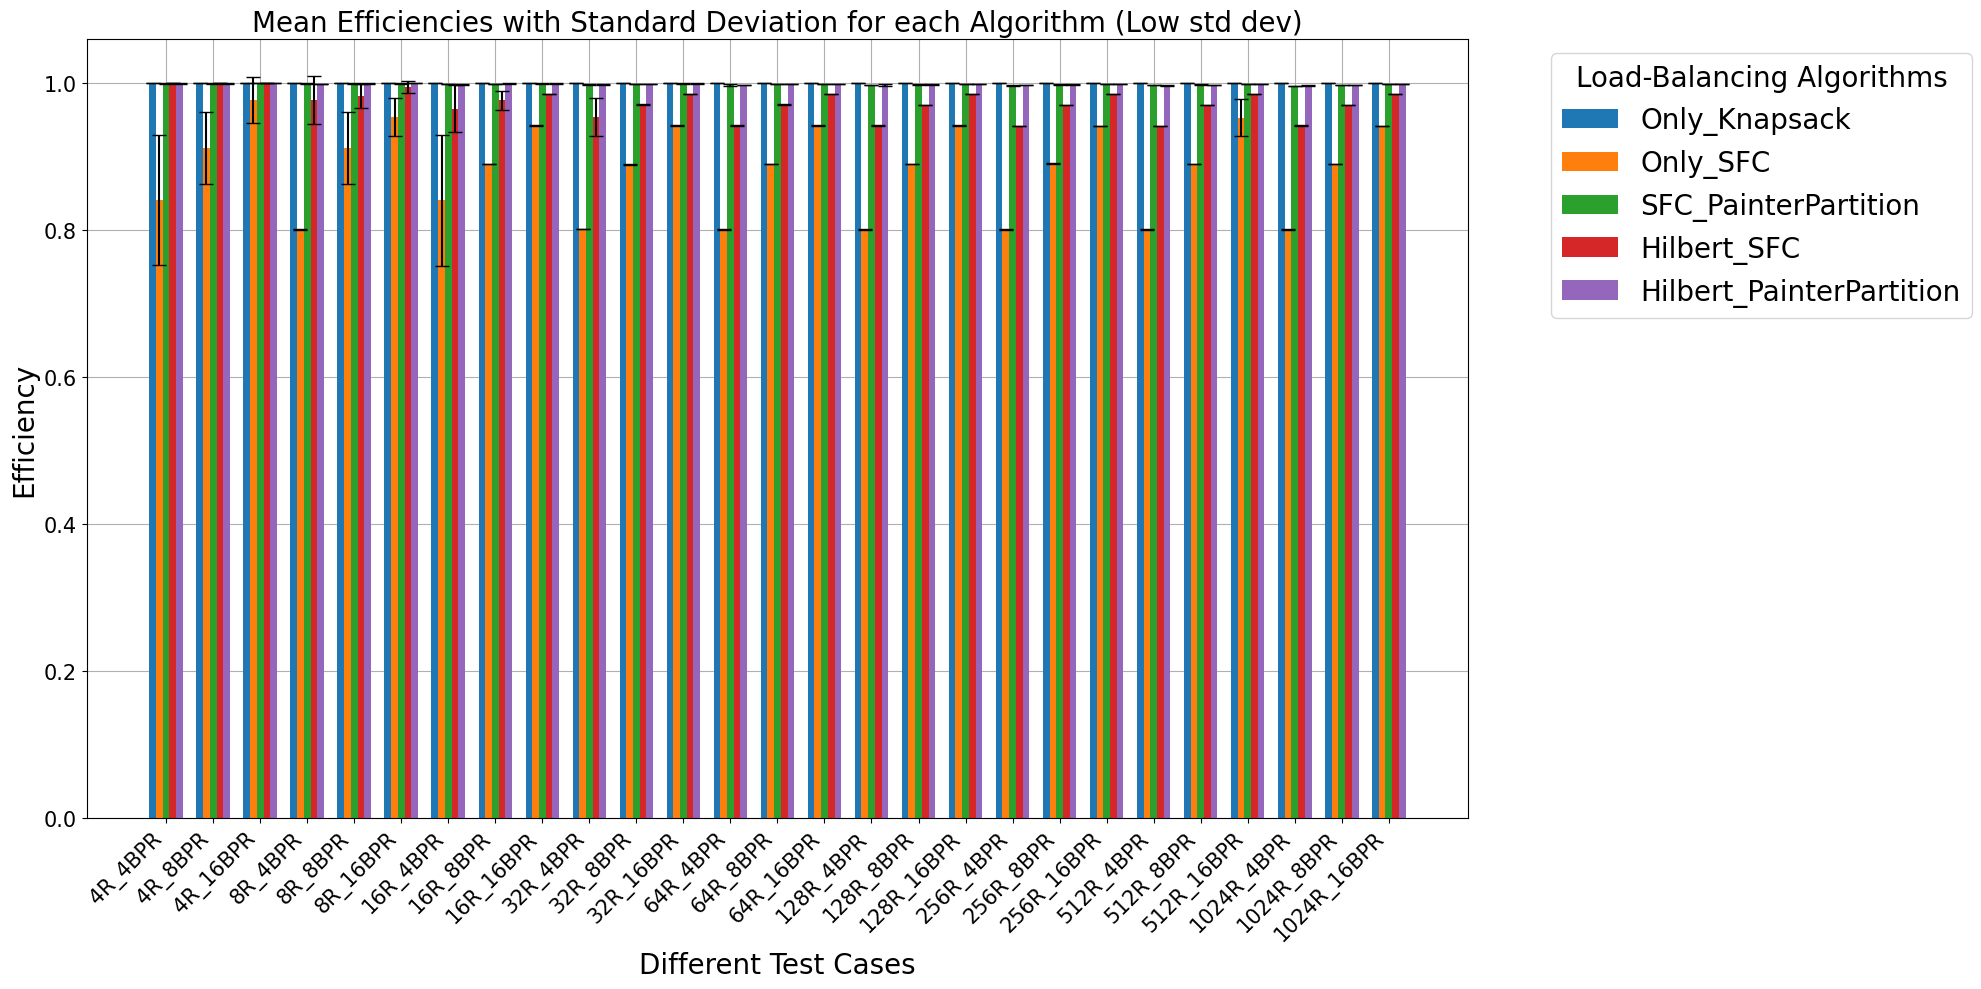

In [26]:
# algorithms = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC', 'Hilbert_PainterPartition']
algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
fig, ax = plt.subplots(figsize=(20, 10))
width = 1  
num_algorithms = len(algorithms)
group_gap = 2  
x_spacing = num_algorithms * width + group_gap
x = np.arange(len(grouped['File'])) * x_spacing

for i, alg in enumerate(algorithms):
    mean_col = f'{alg}_Efficiency_mean'
    std_col = f'{alg}_Efficiency_std'
    ax.bar(x + i * width, grouped[mean_col], width,
           yerr=grouped[std_col], capsize=5, label=alg)
    
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel('Different Test Cases', fontsize=20)
ax.set_ylabel('Efficiency', fontsize=20)
ax.set_title('Mean Efficiencies with Standard Deviation for each Algorithm (Low std dev)', fontsize=20)
ax.set_xticks(x + width * (num_algorithms - 1) / 2)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(title='Load-Balancing Algorithms', title_fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)

plt.margins(x=0.05)
plt.tight_layout()
# plt.savefig('../result/new_result/result_best/efficiency_errorbarplot.png', dpi=600)
plt.show()

In [27]:
# algorithms = [
#     ('Only_Knapsack', 'Only_Knapsack_Efficiency', 'Only_Knapsack_Final_Time'),
#     ('Only_SFC', 'Only_SFC_Efficiency', 'Only_SFC_Final_Time'),
#     ('SFC_PainterPartition', 'SFC_PainterPartition_Efficiency', 'SFC_PainterPartition_Final_Time'),
#     ('SFC_Knapsack_Combined', 'SFC_Knapsack_Combined_Efficiency', 'SFC_Knapsack_Combined_Final_Time')
# ]

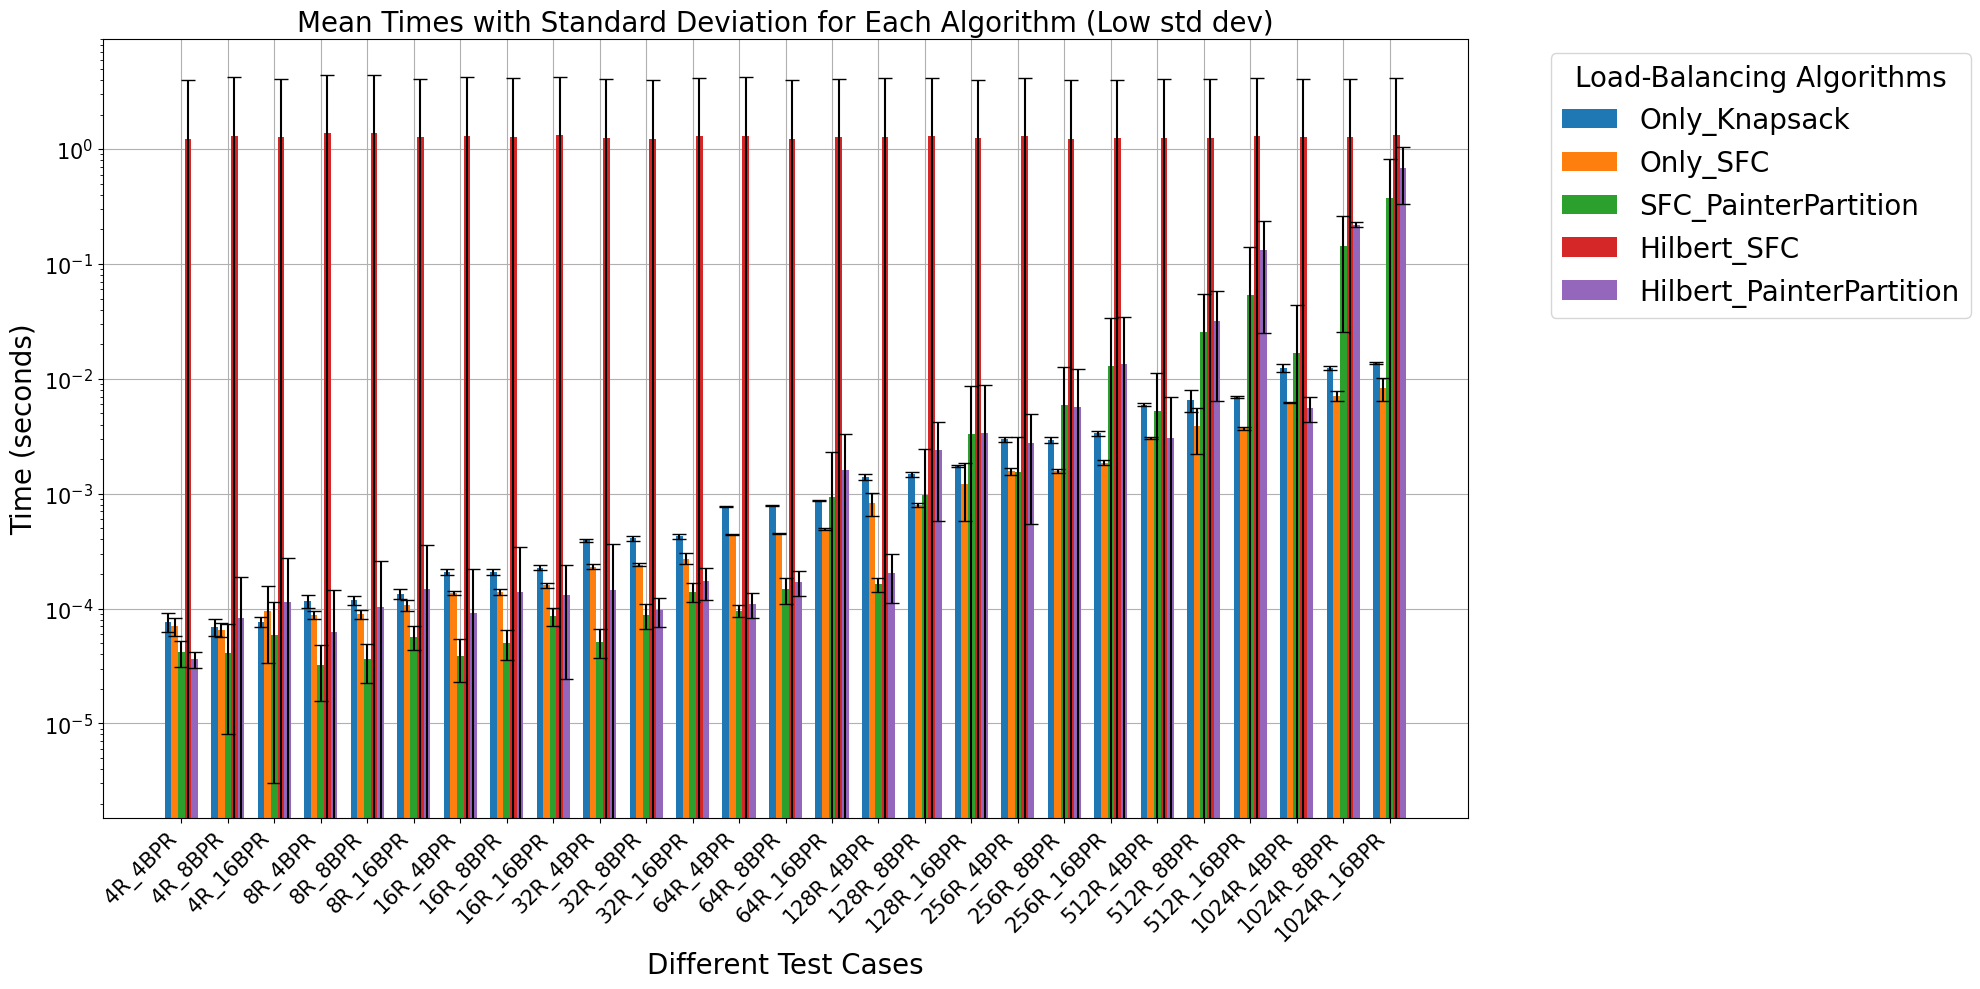

In [28]:

# time = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC']
time = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
fig, ax = plt.subplots(figsize=(20, 10))
width = 1  
num_algorithms = len(time)
group_gap = 2  
x_spacing = num_algorithms * width + group_gap
x = np.arange(len(grouped['File'])) * x_spacing

for i, alg in enumerate(time):
    mean_col = f'{alg}_Final_Time_mean'
    std_col = f'{alg}_Final_Time_std'
    ax.bar(x + i * width, grouped[mean_col], width,
           yerr=grouped[std_col], capsize=5, label=alg)
ax.grid(True)
ax.set_axisbelow(True)
# Set y-axis to logarithmic scale
ax.set_yscale('log')

ax.set_xlabel('Different Test Cases', fontsize=20)
ax.set_ylabel('Time (seconds)', fontsize=20)
ax.set_title('Mean Times with Standard Deviation for Each Algorithm (Low std dev)', fontsize=20)
ax.set_xticks(x + width*(len(time)-1)/2)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(title='Load-Balancing Algorithms', title_fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
plt.margins(x=0.05)
plt.tight_layout()
# plt.savefig('../result/new_result/result_best/time_errorbarplot.png', dpi=600)
plt.show()

In [29]:
# algorithms = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC', 'Hilbert_PainterPartition']
algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']

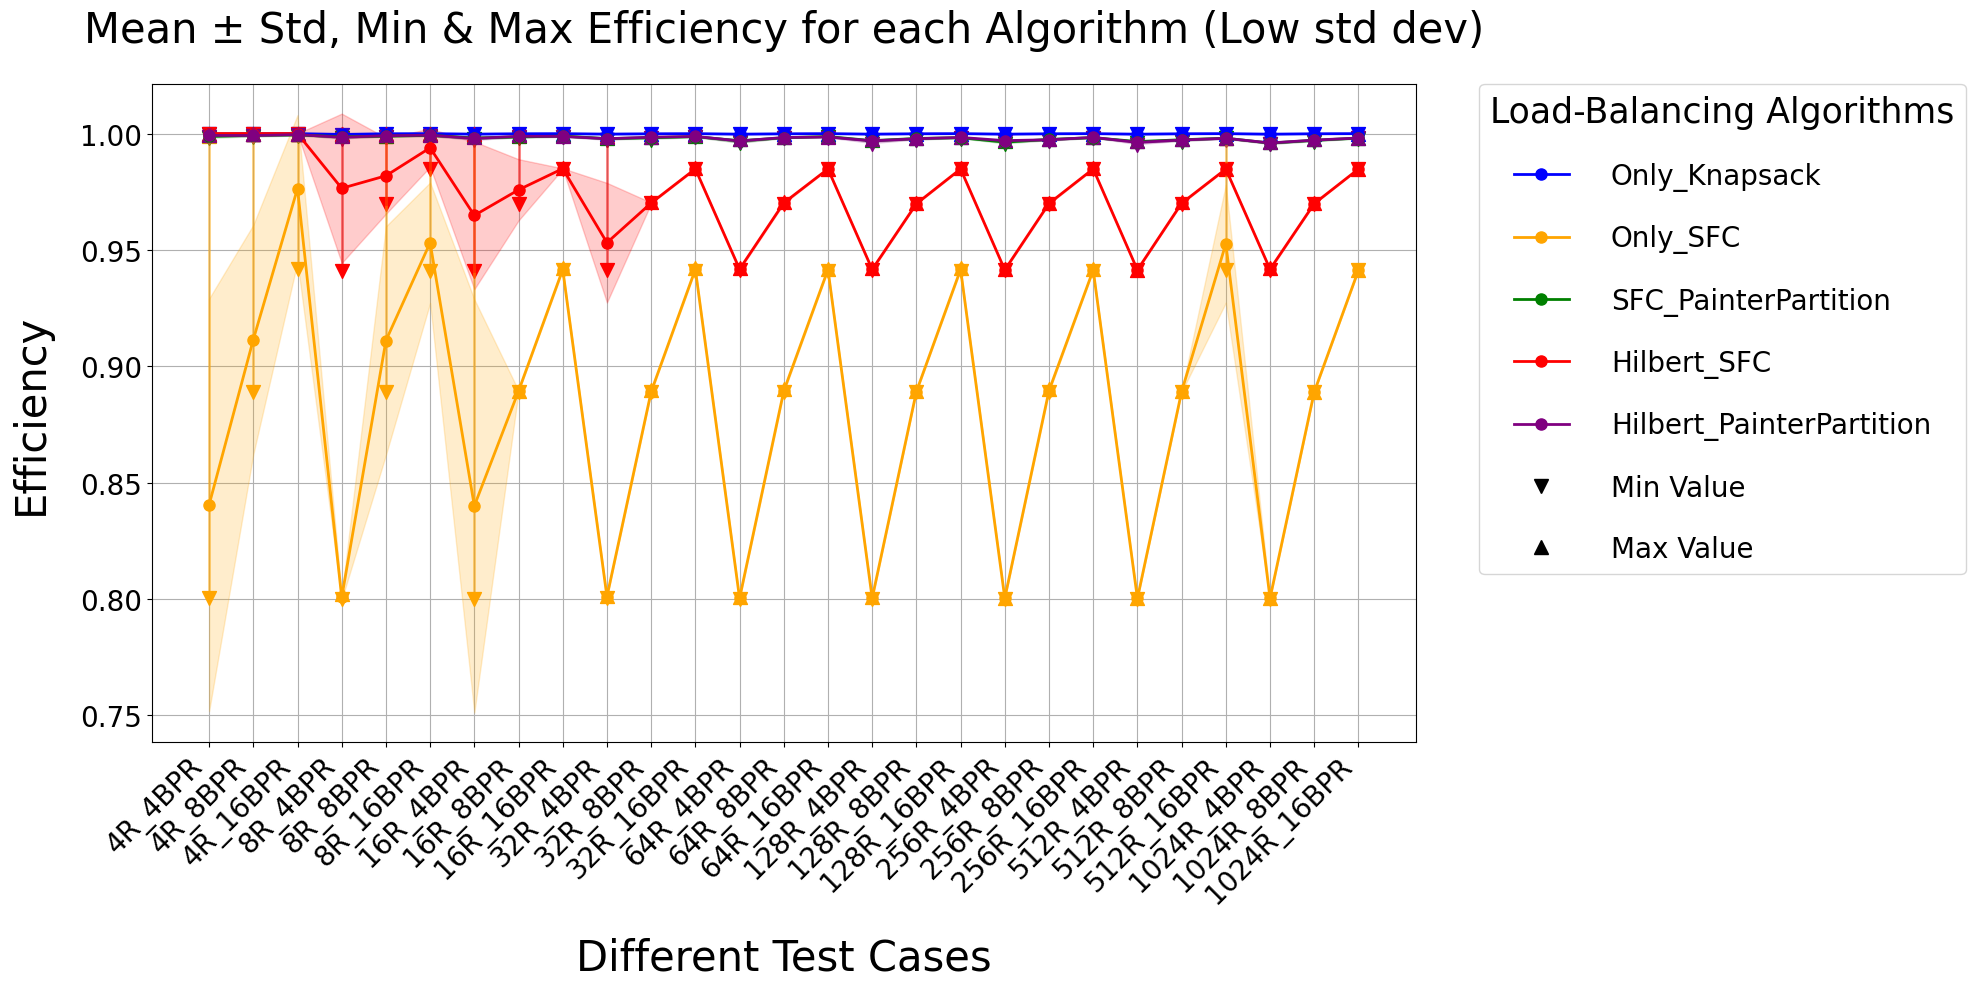

In [30]:

# algorithms = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC']
algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  


    mean_col = f'{alg_name}_Efficiency_mean'
    std_col = f'{alg_name}_Efficiency_std'
    min_col = f'{alg_name}_Efficiency_min'
    max_col = f'{alg_name}_Efficiency_max'

    alg_color = colors[i]
    ax.plot(x, grouped[mean_col], marker='o', color=alg_color, label=alg_name, linewidth=2, markersize=8)
    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
    for j, file_name in enumerate(grouped['File']):
        min_val = grouped[min_col].iloc[j]
        max_val = grouped[max_col].iloc[j]
        ax.plot([x[j], x[j]], [min_val, max_val], color=alg_color, alpha=0.5, linewidth=2)
        ax.scatter(x[j], min_val, color=alg_color, marker='v', s=100)
        ax.scatter(x[j], max_val, color=alg_color, marker='^', s=100)

ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases',  fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30,labelpad=20)
ax.set_title('Mean ± Std, Min & Max Efficiency for each Algorithm (Low std dev)', pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

import matplotlib.lines as mlines
min_marker = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=10, label='Min Value')
max_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='Max Value')

handles, labels = ax.get_legend_handles_labels()
handles += [min_marker, max_marker]
labels += ['Min Value', 'Max Value']

ax.legend(handles, labels, title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,labelspacing=1.2, handletextpad=1.5)
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('../result/new_result/result_best/efficiency_all_stats.png', dpi=600)
plt.show()





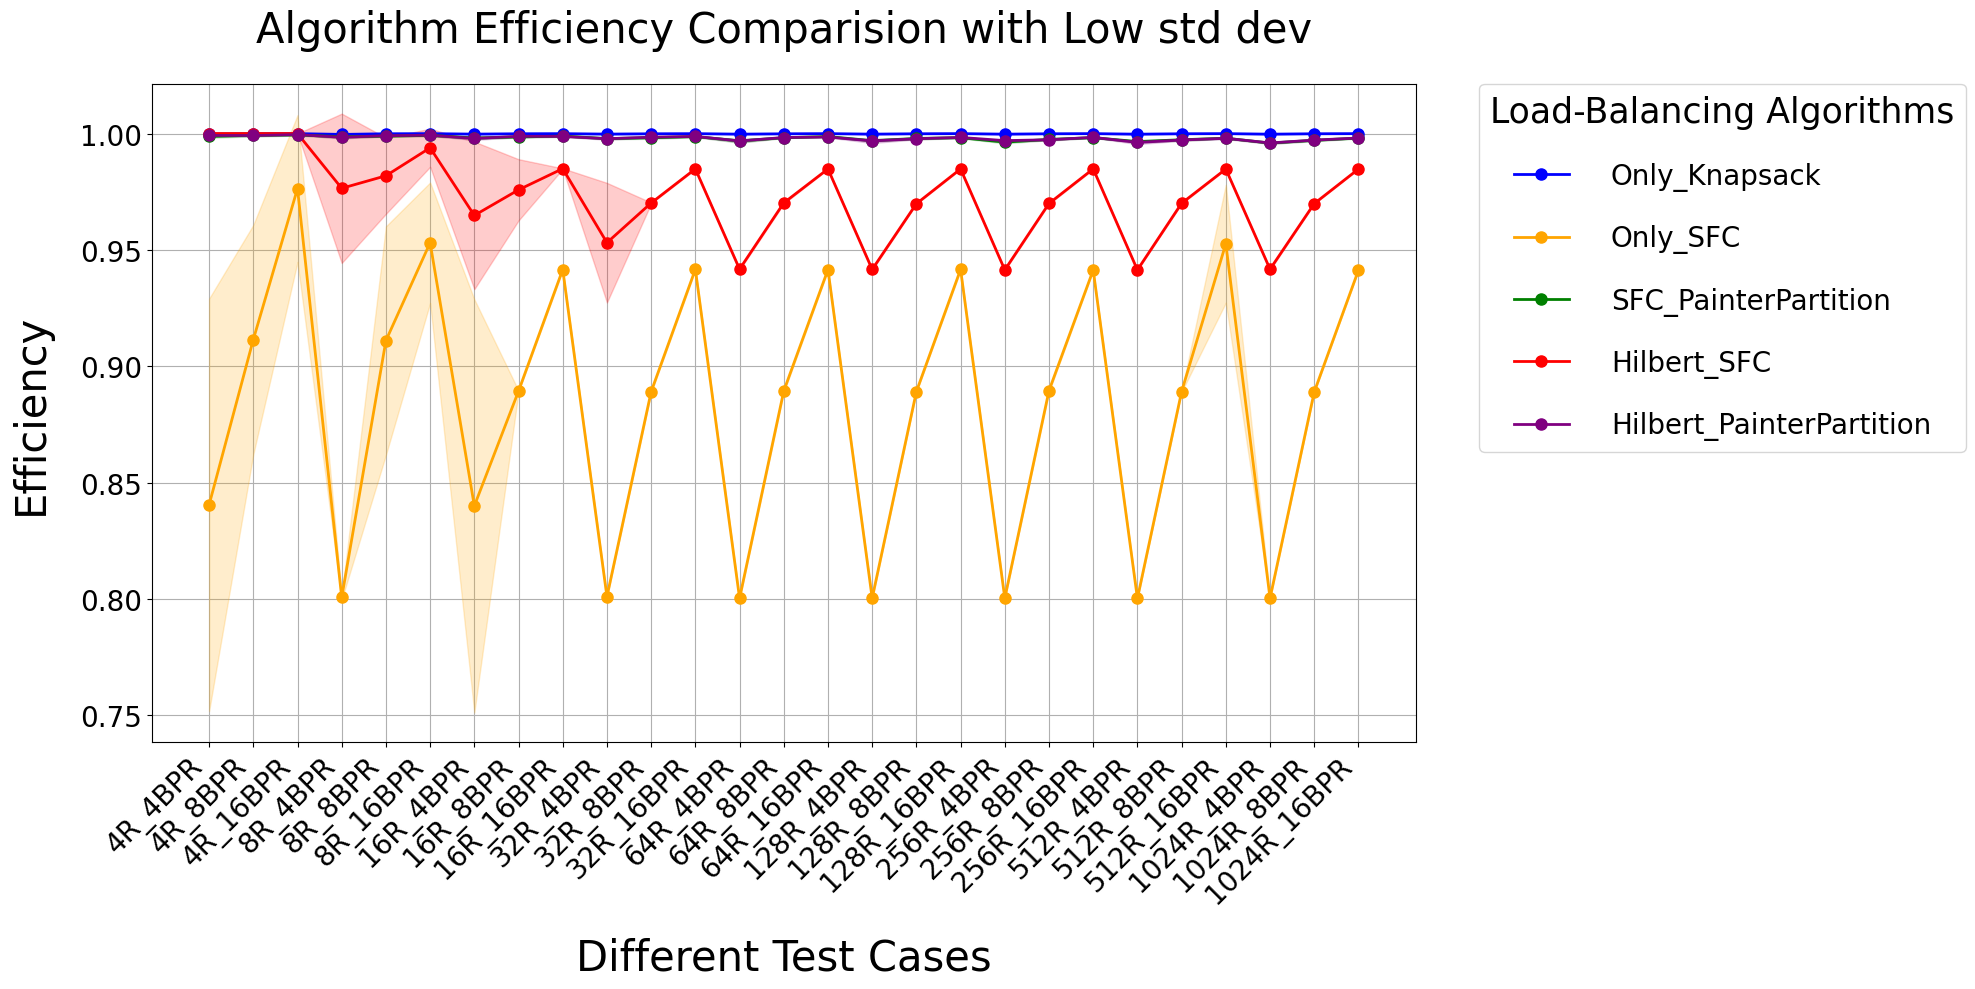

In [31]:
# algorithms = [
#     'Only_Knapsack', 
#     'SFC_PainterPartition', 
#     'Painter_Knapsack_Combined', 
#     'Only_SFC', 
#     'SFC_Knapsack_Combined',
#     'Hilbert_SFC'
# ]
algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  
    
    mean_col = f'{alg_name}_Efficiency_mean'
    std_col  = f'{alg_name}_Efficiency_std'

    alg_color = colors[i]

    ax.plot(
        x, 
        grouped[mean_col], 
        marker='o', 
        color=alg_color, 
        label=alg_name, 
        linewidth=2, 
        markersize=8
    )

    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')

ax.set_xlabel('Different Test Cases', fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30, labelpad=20)
ax.set_title('Algorithm Efficiency Comparision with Low std dev',
             pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

ax.legend(
    title='Load-Balancing Algorithms', 
    title_fontsize=25, 
    fontsize=20,
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    labelspacing=1.2, 
    handletextpad=1.5
)

ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../result/result_best/efficiency_all_stats_nominmax.png', dpi=600)
plt.show()

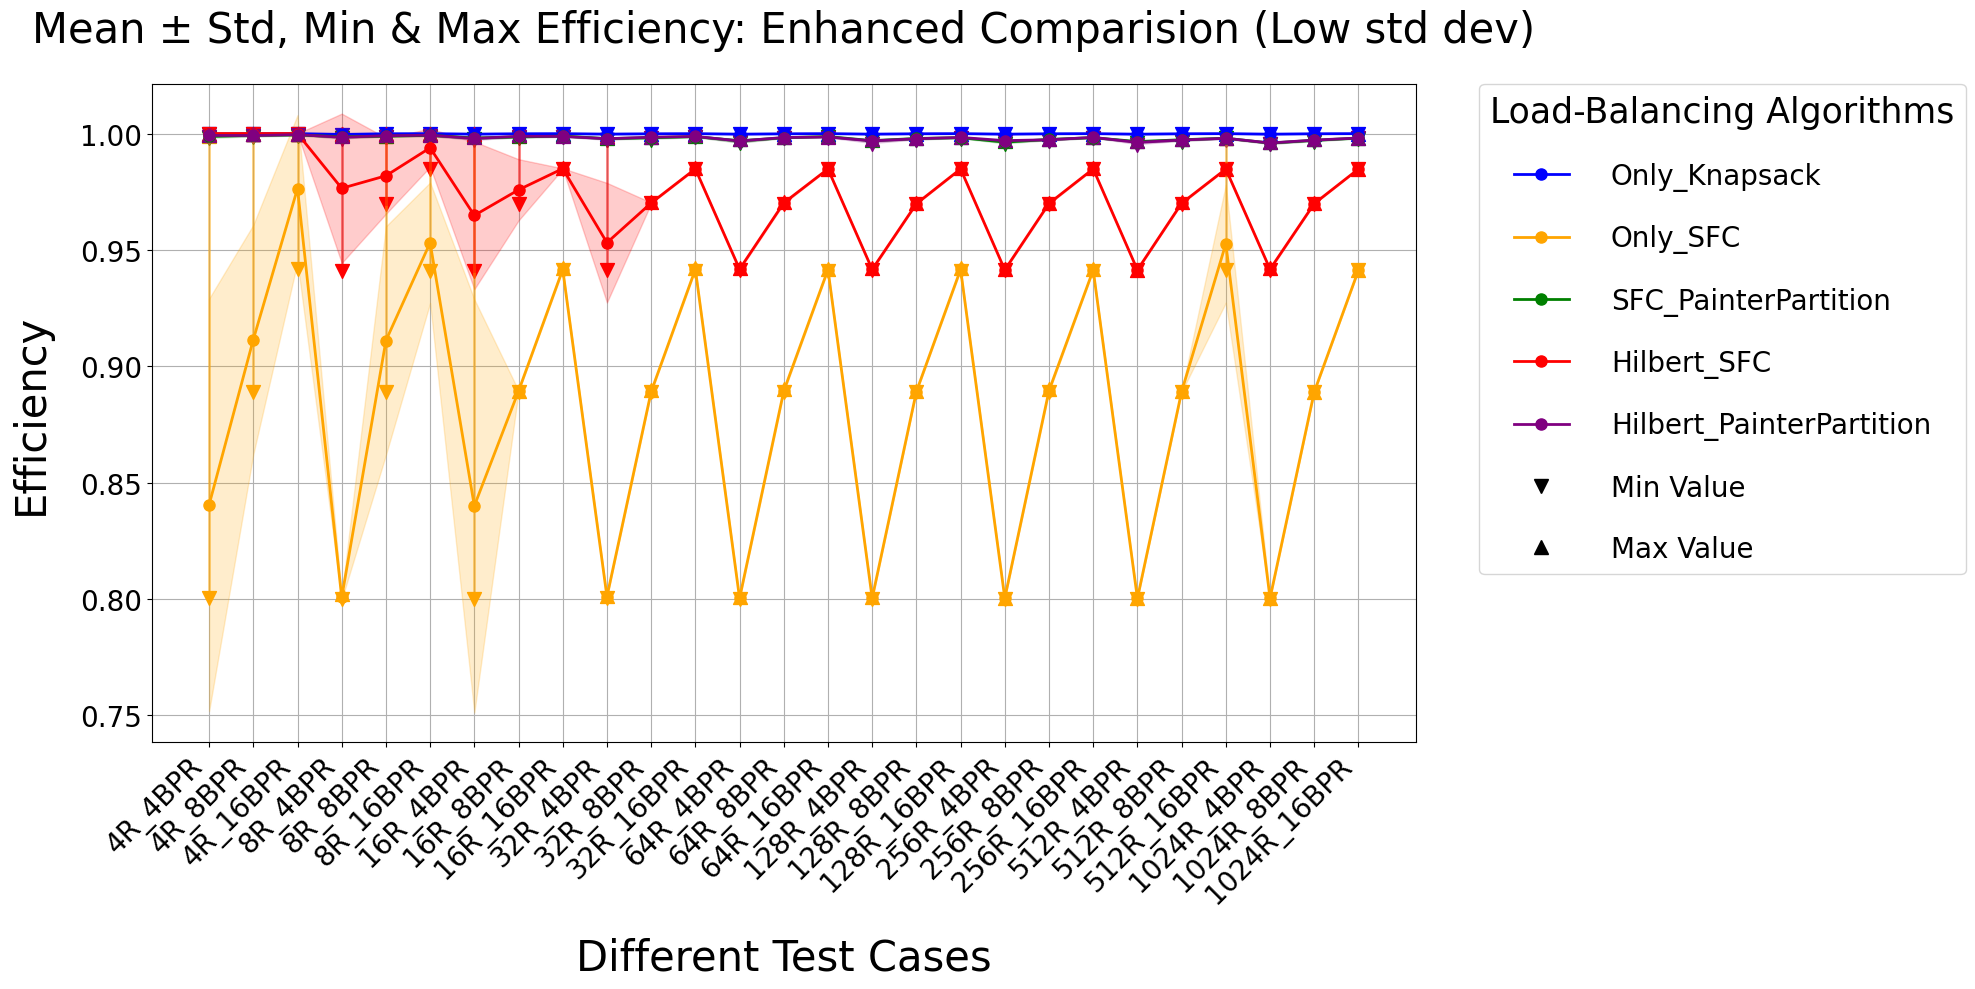

In [32]:


# algorithms = ['Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC', 'Hilbert_PainterPartition']
algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  


    mean_col = f'{alg_name}_Efficiency_mean'
    std_col = f'{alg_name}_Efficiency_std'
    min_col = f'{alg_name}_Efficiency_min'
    max_col = f'{alg_name}_Efficiency_max'

    alg_color = colors[i]
    ax.plot(x, grouped[mean_col], marker='o', color=alg_color, label=alg_name, linewidth=2, markersize=8)
    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
    for j, file_name in enumerate(grouped['File']):
        min_val = grouped[min_col].iloc[j]
        max_val = grouped[max_col].iloc[j]
        ax.plot([x[j], x[j]], [min_val, max_val], color=alg_color, alpha=0.5, linewidth=2)
        ax.scatter(x[j], min_val, color=alg_color, marker='v', s=100)
        ax.scatter(x[j], max_val, color=alg_color, marker='^', s=100)

ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases',  fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30,labelpad=20)
ax.set_title('Mean ± Std, Min & Max Efficiency: Enhanced Comparision (Low std dev)', pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

import matplotlib.lines as mlines
min_marker = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=10, label='Min Value')
max_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='Max Value')

handles, labels = ax.get_legend_handles_labels()
handles += [min_marker, max_marker]
labels += ['Min Value', 'Max Value']

ax.legend(handles, labels, title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,labelspacing=1.2, handletextpad=1.5)
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('../result/new_result/result_best/efficiency_all_stats_2.png', dpi=600)
plt.show()



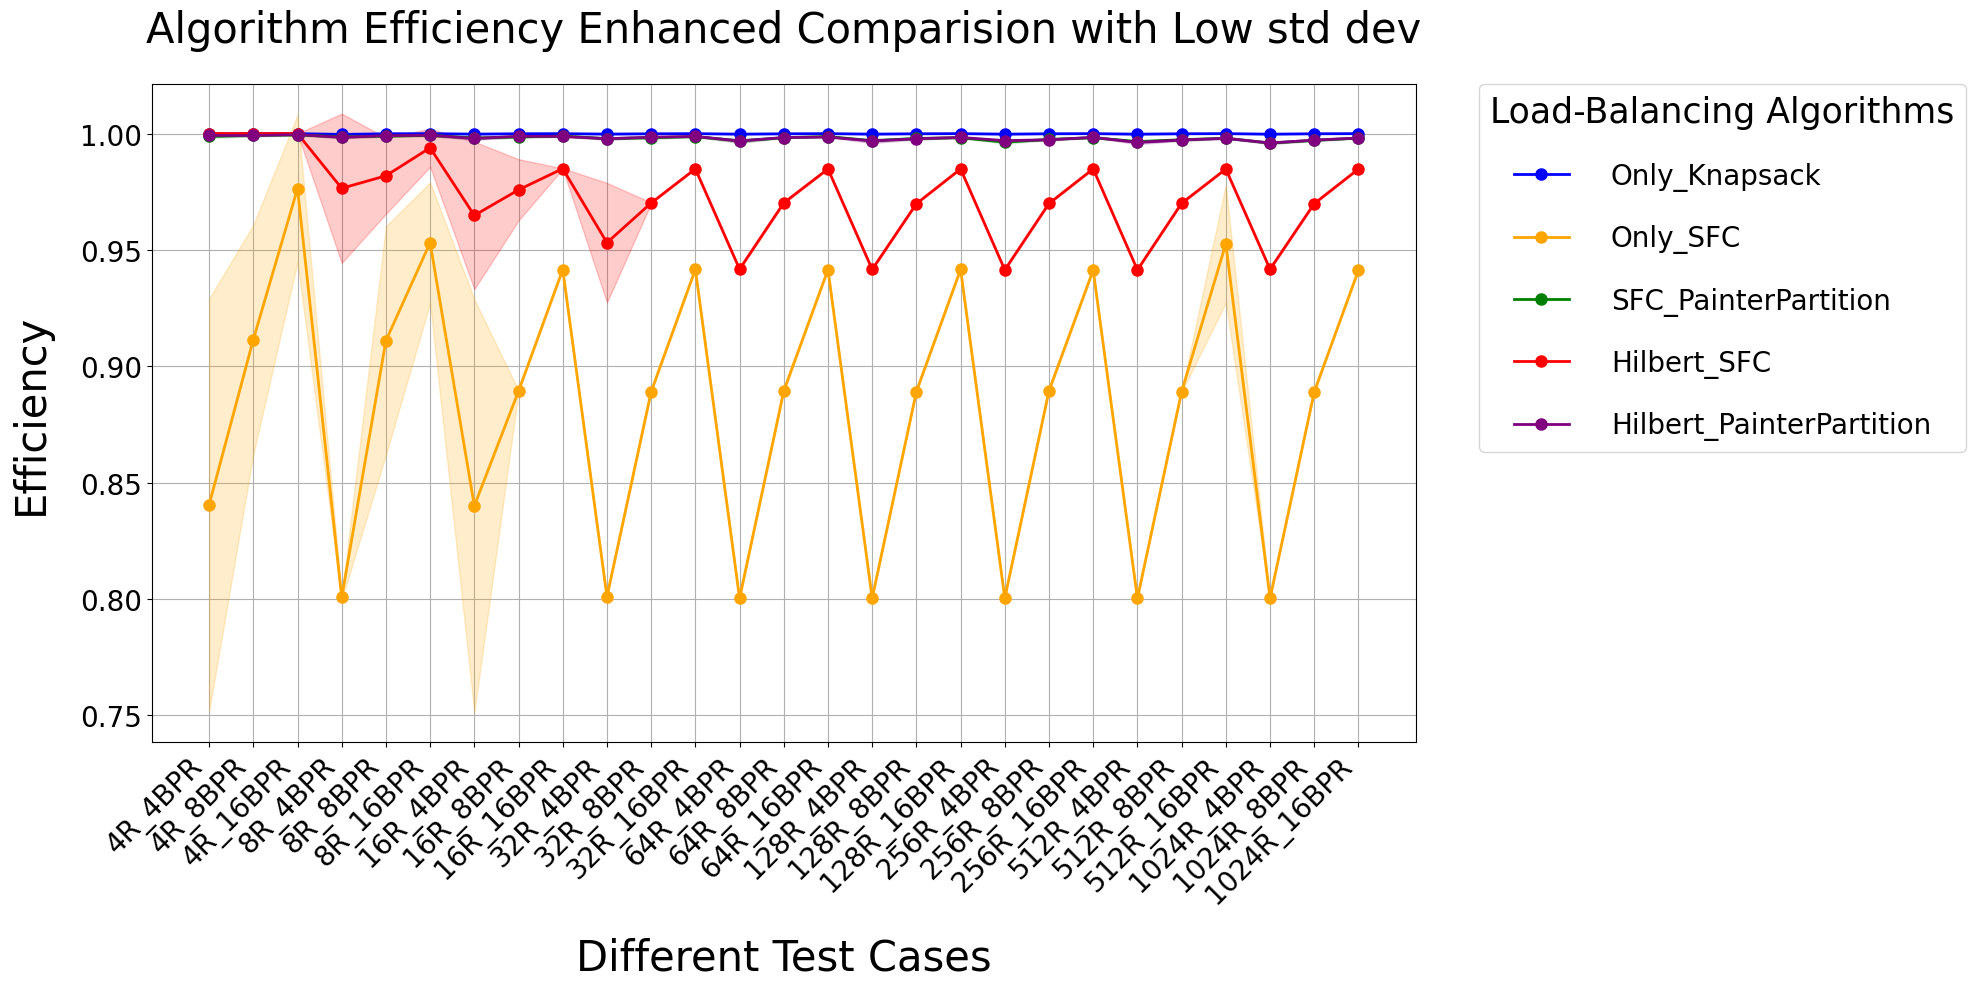

In [33]:
# algorithms = ['Only_SFC', 'SFC_Knapsack_Combined', 'Hilbert_SFC']
# colors = ['red', 'purple', 'cyan']

algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  
    
    mean_col = f'{alg_name}_Efficiency_mean'
    std_col  = f'{alg_name}_Efficiency_std'

    alg_color = colors[i]

    ax.plot(
        x, 
        grouped[mean_col], 
        marker='o', 
        color=alg_color, 
        label=alg_name, 
        linewidth=2, 
        markersize=8
    )

    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')

ax.set_xlabel('Different Test Cases', fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30, labelpad=20)
ax.set_title('Algorithm Efficiency Enhanced Comparision with Low std dev',
             pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

ax.legend(
    title='Load-Balancing Algorithms', 
    title_fontsize=25, 
    fontsize=20,
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    labelspacing=1.2, 
    handletextpad=1.5
)

ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../result/result_best/efficiency_all_stats_2_nominmax.png', dpi=600)
plt.show()

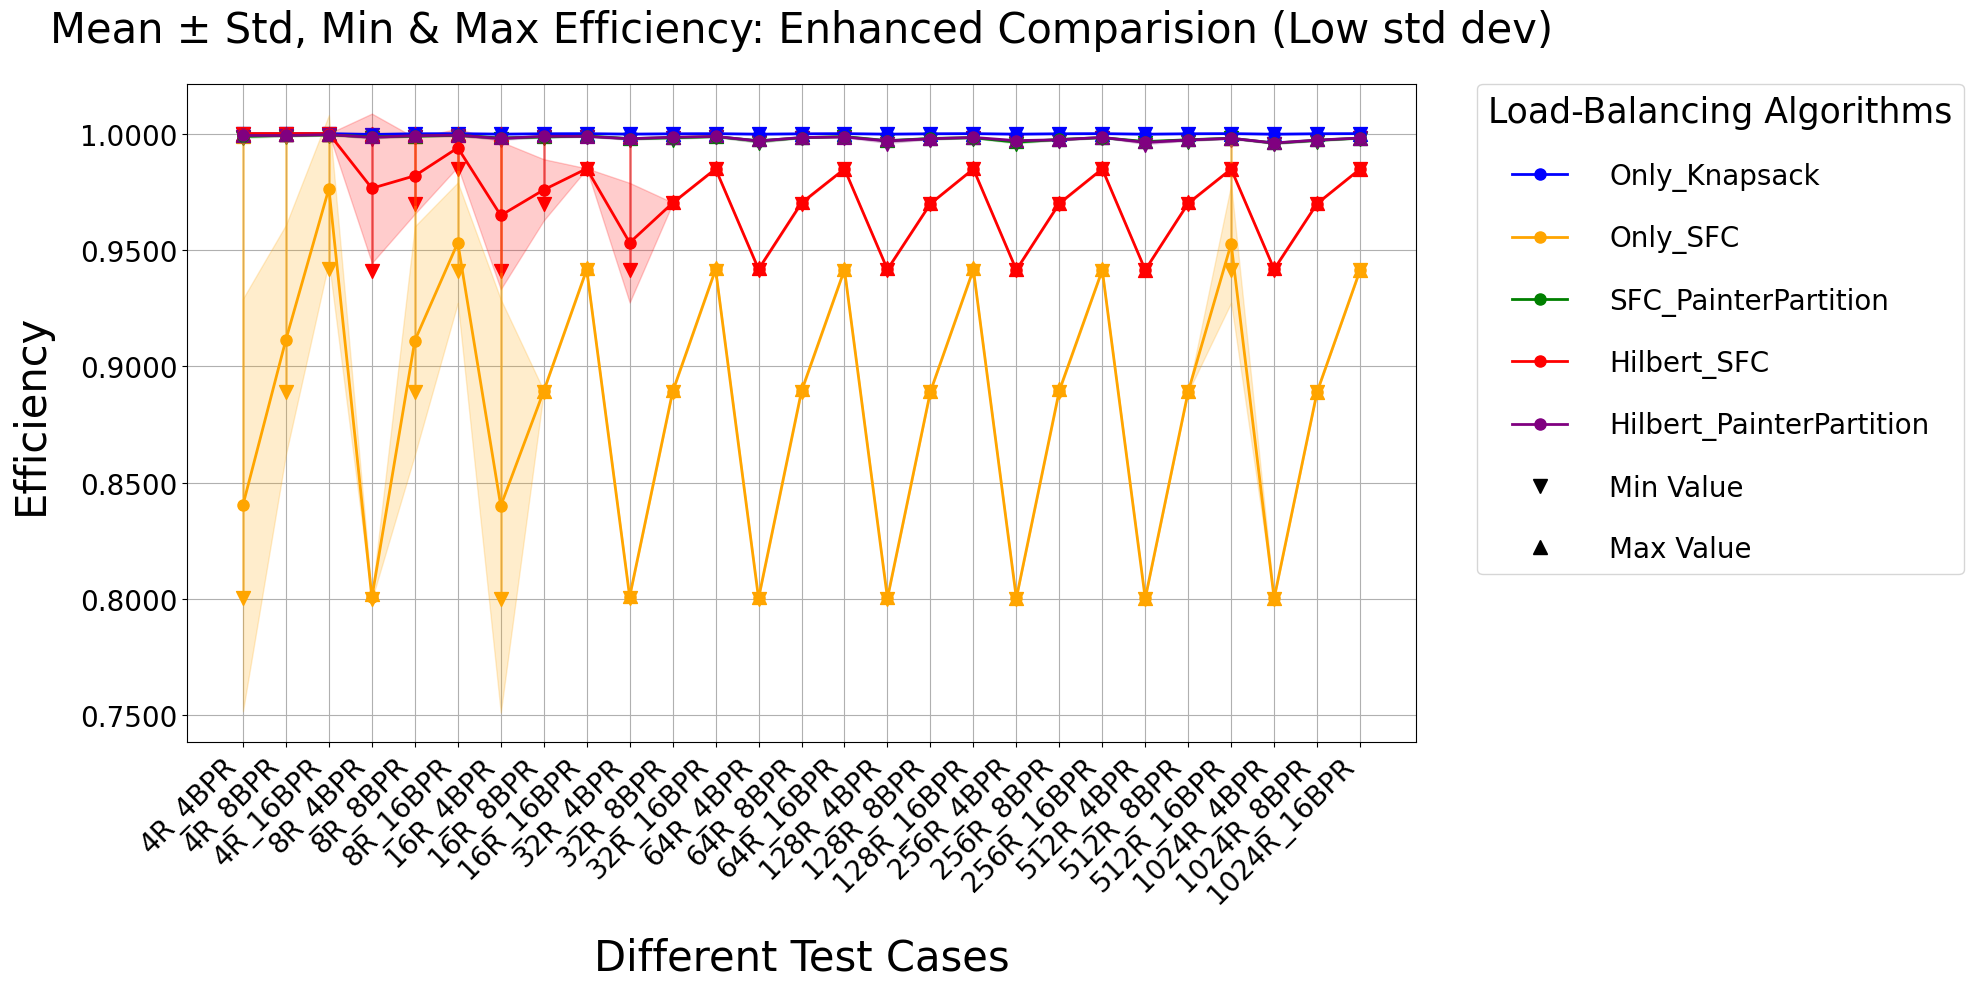

In [34]:
# algorithms = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined']
# colors = ['blue', 'orange', 'green', 'red', 'purple']


# algorithms = ['Only_Knapsack', 'SFC_PainterPartition','Painter_Knapsack_Combined', 'Hilbert_SFC']
# colors = ['blue','orange', 'green', 'cyan']

algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  

    mean_col = f'{alg_name}_Efficiency_mean'
    std_col = f'{alg_name}_Efficiency_std'
    min_col = f'{alg_name}_Efficiency_min'
    max_col = f'{alg_name}_Efficiency_max'

    alg_color = colors[i]
    ax.plot(x, grouped[mean_col], marker='o', color=alg_color, label=alg_name, linewidth=2, markersize=8)
    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
    for j, file_name in enumerate(grouped['File']):
        min_val = grouped[min_col].iloc[j]
        max_val = grouped[max_col].iloc[j]
        ax.plot([x[j], x[j]], [min_val, max_val], color=alg_color, alpha=0.5, linewidth=2)
        ax.scatter(x[j], min_val, color=alg_color, marker='v', s=100)
        ax.scatter(x[j], max_val, color=alg_color, marker='^', s=100)

ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases', fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30, labelpad=20)
ax.set_title('Mean ± Std, Min & Max Efficiency: Enhanced Comparision (Low std dev)', pad=30, fontsize=30)
# ax.set_ylim(0.990, 1.0005)

ax.tick_params(axis='both', which='major', labelsize=20)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
min_marker = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=10, label='Min Value')
max_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='Max Value')
handles, labels = ax.get_legend_handles_labels()
handles += [min_marker, max_marker]
labels += ['Min Value', 'Max Value']

ax.legend(handles, labels, title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20,
          bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., labelspacing=1.2, handletextpad=1.5)
ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig('../result/new_result/result_best/efficiency_all_stats_3.png', dpi=600)
plt.show()


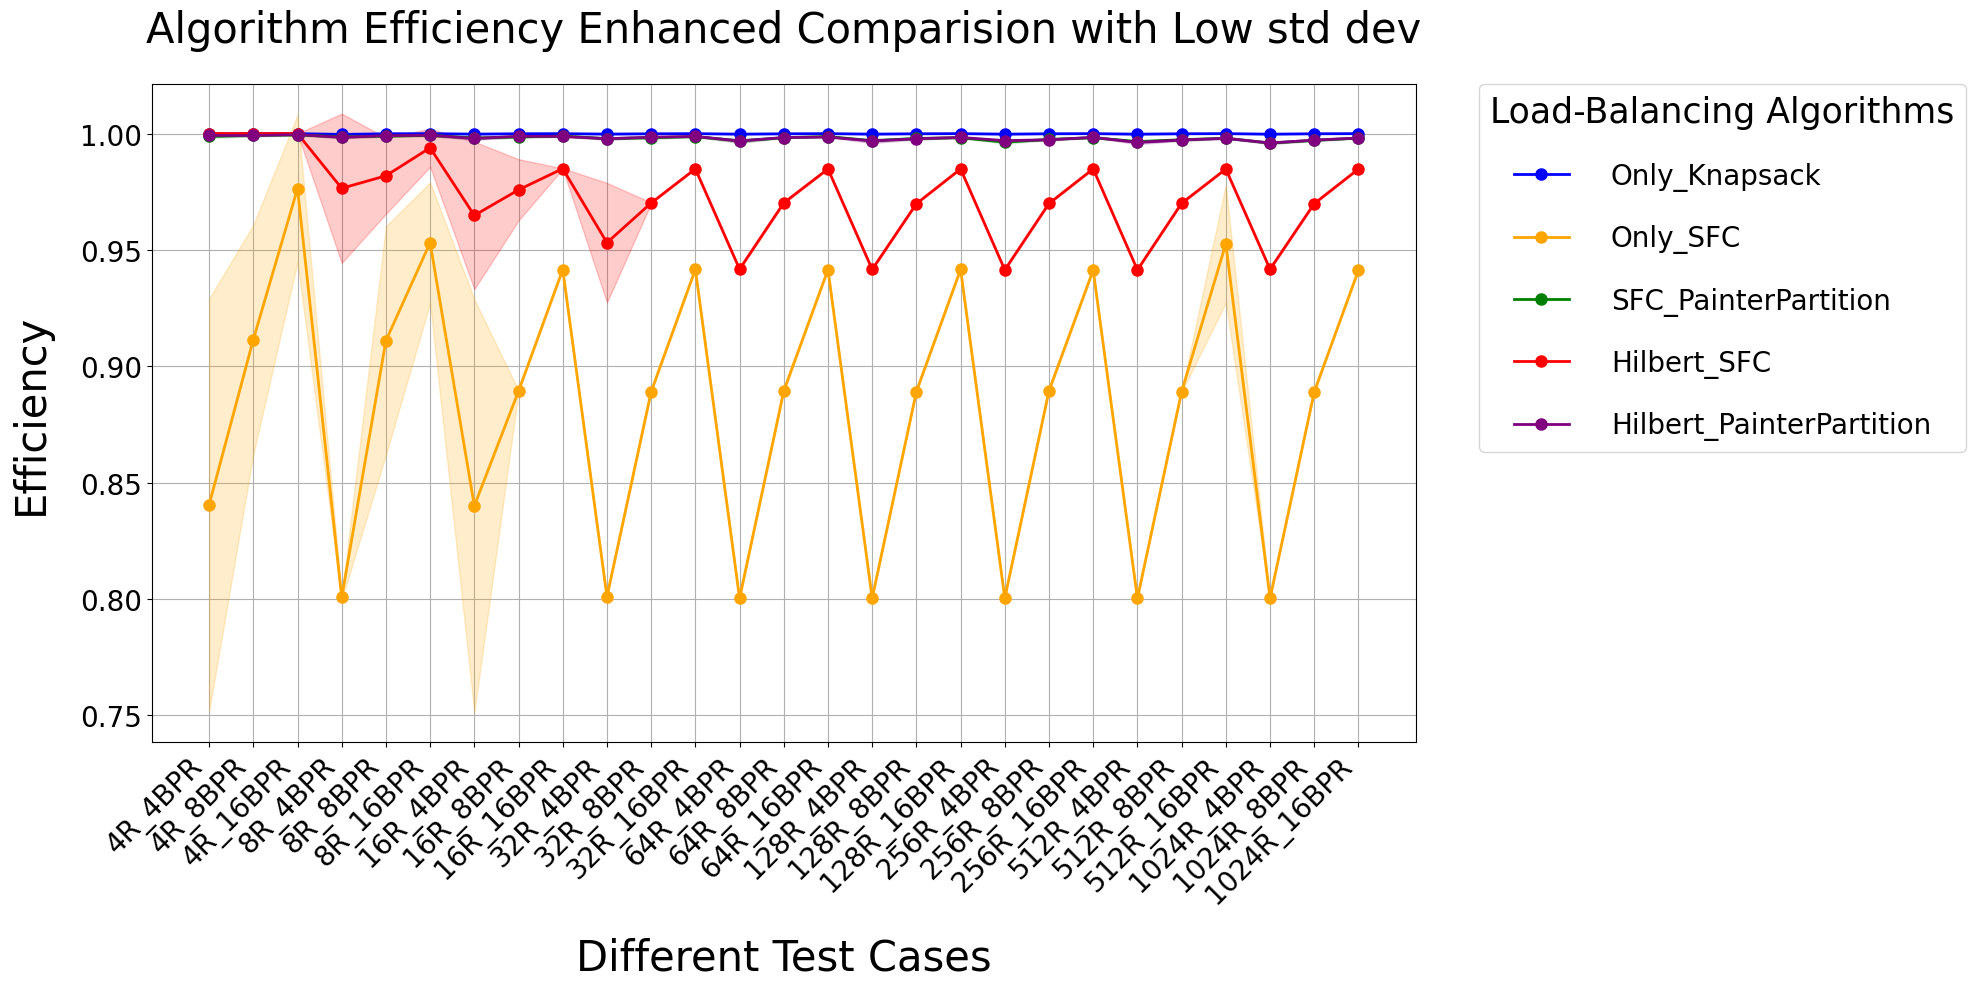

In [35]:

# algorithms = ['Only_Knapsack', 'SFC_PainterPartition','Painter_Knapsack_Combined', 'Hilbert_SFC']
# colors = ['blue','orange', 'green', 'cyan']

algorithms = ['Only_Knapsack', 'Only_SFC', 'SFC_PainterPartition', 'Hilbert_SFC', 'Hilbert_PainterPartition']
colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, ax = plt.subplots(figsize=(20, 10))

for i, alg in enumerate(algorithms):
    alg_name = alg  
    
    mean_col = f'{alg_name}_Efficiency_mean'
    std_col  = f'{alg_name}_Efficiency_std'

    alg_color = colors[i]

    ax.plot(
        x, 
        grouped[mean_col], 
        marker='o', 
        color=alg_color, 
        label=alg_name, 
        linewidth=2, 
        markersize=8
    )

    ax.fill_between(
        x,
        grouped[mean_col] - grouped[std_col],
        grouped[mean_col] + grouped[std_col],
        color=alg_color,
        alpha=0.2
    )
ax.set_xticks(x)
ax.set_xticklabels(grouped['File'], rotation=45, ha='right')

ax.set_xlabel('Different Test Cases', fontsize=30, labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30, labelpad=20)
ax.set_title('Algorithm Efficiency Enhanced Comparision with Low std dev',
             pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

ax.legend(
    title='Load-Balancing Algorithms', 
    title_fontsize=25, 
    fontsize=20,
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    labelspacing=1.2, 
    handletextpad=1.5
)

ax.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../result/result_best/efficiency_all_stats_3_nominmax.png', dpi=600)
plt.show()

In [36]:
grouped

,File,Only_Knapsack_Efficiency_mean,Only_Knapsack_Efficiency_std,Only_Knapsack_Efficiency_min,Only_Knapsack_Efficiency_max,SFC_PainterPartition_Efficiency_mean,SFC_PainterPartition_Efficiency_std,SFC_PainterPartition_Efficiency_min,SFC_PainterPartition_Efficiency_max,Painter_Knapsack_Combined_Efficiency_mean,Painter_Knapsack_Combined_Efficiency_std,Painter_Knapsack_Combined_Efficiency_min,Painter_Knapsack_Combined_Efficiency_max,Only_SFC_Efficiency_mean,Only_SFC_Efficiency_std,Only_SFC_Efficiency_min,Only_SFC_Efficiency_max,SFC_Knapsack_Combined_Efficiency_mean,SFC_Knapsack_Combined_Efficiency_std,SFC_Knapsack_Combined_Efficiency_min,SFC_Knapsack_Combined_Efficiency_max,Hilbert_SFC_Efficiency_mean,Hilbert_SFC_Efficiency_std,Hilbert_SFC_Efficiency_min,Hilbert_SFC_Efficiency_max,Hilbert_PainterPartition_Efficiency_mean,Hilbert_PainterPartition_Efficiency_std,Hilbert_PainterPartition_Efficiency_min,Hilbert_PainterPartition_Efficiency_max,Only_Knapsack_Final_Time_mean,Only_Knapsack_Final_Time_std,Only_Knapsack_Final_Time_min,Only_Knapsack_Final_Time_max,SFC_PainterPartition_Final_Time_mean,SFC_PainterPartition_Final_Time_std,SFC_PainterPartition_Final_Time_min,SFC_PainterPartition_Final_Time_max,Painter_Knapsack_Combined_Final_Time_mean,Painter_Knapsack_Combined_Final_Time_std,Painter_Knapsack_Combined_Final_Time_min,Painter_Knapsack_Combined_Final_Time_max,Only_SFC_Final_Time_mean,Only_SFC_Final_Time_std,Only_SFC_Final_Time_min,Only_SFC_Final_Time_max,SFC_Knapsack_Combined_Final_Time_mean,SFC_Knapsack_Combined_Final_Time_std,SFC_Knapsack_Combined_Final_Time_min,SFC_Knapsack_Combined_Final_Time_max,Hilbert_SFC_Final_Time_mean,Hilbert_SFC_Final_Time_std,Hilbert_SFC_Final_Time_min,Hilbert_SFC_Final_Time_max,Hilbert_PainterPartition_Final_Time_mean,Hilbert_PainterPartition_Final_Time_std,Hilbert_PainterPartition_Final_Time_min,Hilbert_PainterPartition_Final_Time_max
0,4R_4BPR,0.999795,0.000126,0.999647,0.999966,0.998752,0.000555,0.997998,0.999506,0.999795,0.000126,0.999647,0.999966,0.840464,0.088597,0.800558,0.998951,0.999795,0.000126,0.999647,0.999966,1.000000,0.000000,1.000000,1.000000,0.999190,0.000340,0.998642,0.999544,0.000077,0.000014,0.000060,0.000088,0.000041,0.000010,0.000031,0.000055,0.000061,0.000008,0.000047,0.000067,0.000070,0.000012,0.000055,0.000083,0.000053,0.000007,0.000041,0.000060,1.224848,2.738075,0.000268,6.122866,0.000036,0.000005,0.000028,0.000041
1,4R_8BPR,0.999903,0.000044,0.999845,0.999961,0.999237,0.000504,0.998564,0.999837,0.999903,0.000044,0.999845,0.999961,0.911468,0.049270,0.888796,0.999598,0.999903,0.000044,0.999845,0.999961,1.000000,0.000000,1.000000,1.000000,0.999163,0.000314,0.998929,0.999596,0.000069,0.000012,0.000062,0.000090,0.000041,0.000033,0.000023,0.000098,0.000055,0.000008,0.000048,0.000065,0.000065,0.000009,0.000059,0.000081,0.000045,0.000007,0.000041,0.000057,1.313062,2.935395,0.000281,6.564056,0.000082,0.000107,0.000029,0.000272
2,4R_16BPR,0.999958,0.000032,0.999911,0.999992,0.999384,0.000274,0.999032,0.999745,0.999958,0.000032,0.999911,0.999992,0.976357,0.031544,0.941668,0.999745,0.999958,0.000032,0.999911,0.999992,1.000000,0.000000,1.000000,1.000000,0.999533,0.000082,0.999442,0.999605,0.000076,0.000008,0.000070,0.000089,0.000058,0.000055,0.000029,0.000157,0.000062,0.000005,0.000057,0.000070,0.000096,0.000062,0.000064,0.000207,0.000051,0.000008,0.000045,0.000064,1.268394,2.835439,0.000315,6.340581,0.000115,0.000162,0.000036,0.000404
3,8R_4BPR,0.999620,0.000169,0.999391,0.999844,0.998631,0.000637,0.997964,0.999359,0.999421,0.000353,0.998898,0.999760,0.800667,0.000933,0.799935,0.802183,0.920771,0.107996,0.802334,0.999760,0.976469,0.032086,0.940947,0.999934,0.998387,0.000486,0.997555,0.998730,0.000117,0.000015,0.000109,0.000144,0.000032,0.000016,0.000023,0.000061,0.000065,0.000005,0.000062,0.000073,0.000088,0.000008,0.000080,0.000101,0.000059,0.000005,0.000054,0.000068,1.372250,3.067645,0.000265,6.859820,0.000063,0.000083,0.000022,0.000211
4,8R_8BPR,0.999898,0.000056,0.999811,0.999960,0.998

In [37]:

# time = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined']
# colors = ['blue', 'orange', 'green', 'red', 'purple']

# fig, ax = plt.subplots(figsize=(20, 10))

# for i, alg in enumerate(time):
#     alg_name = alg  

#     mean_col = f'{alg_name}_Final_Time_mean'
#     std_col = f'{alg_name}_Final_Time_std'
#     min_col = f'{alg_name}_Final_Time_min'
#     max_col = f'{alg_name}_Final_Time_max'

#     alg_color = colors[i]
#     ax.plot(x, grouped[mean_col], marker='o', color=alg_color, label=alg_name, linewidth=2, markersize=8)
#     lower_bound = np.maximum(grouped[mean_col] - grouped[std_col], 1e-5) 
#     upper_bound = grouped[mean_col] + grouped[std_col]

#     ax.fill_between(
#         x,
#         lower_bound,
#         upper_bound,
#         color=alg_color,
#         alpha=0.2
#     )
#     for j, file_name in enumerate(grouped['File']):
#         min_val = grouped[min_col].iloc[j]
#         max_val = grouped[max_col].iloc[j]
#         ax.plot([x[j], x[j]], [min_val, max_val], color=alg_color, alpha=0.5, linewidth=2)
#         ax.scatter(x[j], min_val, color=alg_color, marker='v', s=100)
#         ax.scatter(x[j], max_val, color=alg_color, marker='^', s=100)

# ax.set_xticks(x)
# ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
# ax.set_xlabel('Different Test Cases', fontsize=30, labelpad=20)
# ax.set_ylabel('Time (seconds)', fontsize=30, labelpad=20)
# ax.set_title('Mean ± Std, Min & Max Time for each Algorithm (Low std dev)', pad=30, fontsize=30)
# ax.tick_params(axis='both', which='major', labelsize=20)
# ax.set_yscale('log')
# ax.set_ylim(1e-6, 0)  

# min_marker = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=10, label='Min Value')
# max_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='Max Value')

# handles, labels = ax.get_legend_handles_labels()
# handles += [min_marker, max_marker]
# labels += ['Min Value', 'Max Value']

# ax.legend(handles, labels, title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20,
#           bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., labelspacing=1.2, handletextpad=1.5)
# ax.grid(True)
# ax.set_axisbelow(True)

# plt.tight_layout()
# # plt.savefig('../result/new_result/result_best/time_all_stats.png', dpi=600)
# plt.show()




In [38]:
# time = ['Only_Knapsack', 'SFC_PainterPartition', 'Painter_Knapsack_Combined', 'Only_SFC', 'SFC_Knapsack_Combined']
# colors = ['blue', 'orange', 'green', 'red', 'purple']

# fig, ax = plt.subplots(figsize=(20, 10))

# for i, alg in enumerate(time):
#     alg_name = alg  

#     mean_col = f'{alg_name}_Final_Time_mean'
#     min_col = f'{alg_name}_Final_Time_min'
#     max_col = f'{alg_name}_Final_Time_max'

#     alg_color = colors[i]

#     ax.plot(x, grouped[mean_col], marker='o', color=alg_color, label=alg_name, linewidth=2, markersize=8)
#     for j, file_name in enumerate(grouped['File']):
#         min_val = grouped[min_col].iloc[j]
#         max_val = grouped[max_col].iloc[j]

#         ax.plot([x[j], x[j]], [min_val, max_val], color=alg_color, alpha=0.5, linewidth=2)

#         ax.scatter(x[j], min_val, color=alg_color, marker='v', s=100)

#         ax.scatter(x[j], max_val, color=alg_color, marker='^', s=100)


# ax.set_xticks(x)
# ax.set_xticklabels(grouped['File'], rotation=45, ha='right')
# ax.set_xlabel('Different Test Cases (R --> Ranks, BPR --> Boxes per Rank)', fontsize=30,labelpad=20)
# ax.set_ylabel('Time (seconds)', fontsize=30,  labelpad=20)
# ax.set_title('Mean, Min & Max Time for each Algorithm (Low std dev)', pad=30, fontsize=30)
# ax.tick_params(axis='both', which='major', labelsize=20)

# ax.set_yscale('log')
# ax.set_ylim(1e-7, 0)  


# min_marker = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=10, label='Min Value')
# max_marker = mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='Max Value')

# handles, labels = ax.get_legend_handles_labels()
# handles += [min_marker, max_marker]
# labels += ['Min Value', 'Max Value']

# ax.legend(handles, labels, title='Load-Balancing Algorithms', title_fontsize=20, fontsize=20,
#           bbox_to_anchor=(1.05, 1), loc='upper left',  borderaxespad=0., labelspacing=1.2, handletextpad=1.5)
# ax.grid(True)
# ax.set_axisbelow(True)

# plt.tight_layout()
# # plt.savefig('../result/new_result/result_best/time_all_stats_2.png', dpi=600)
# plt.show()




In [39]:
grouped

,File,Only_Knapsack_Efficiency_mean,Only_Knapsack_Efficiency_std,Only_Knapsack_Efficiency_min,Only_Knapsack_Efficiency_max,SFC_PainterPartition_Efficiency_mean,SFC_PainterPartition_Efficiency_std,SFC_PainterPartition_Efficiency_min,SFC_PainterPartition_Efficiency_max,Painter_Knapsack_Combined_Efficiency_mean,Painter_Knapsack_Combined_Efficiency_std,Painter_Knapsack_Combined_Efficiency_min,Painter_Knapsack_Combined_Efficiency_max,Only_SFC_Efficiency_mean,Only_SFC_Efficiency_std,Only_SFC_Efficiency_min,Only_SFC_Efficiency_max,SFC_Knapsack_Combined_Efficiency_mean,SFC_Knapsack_Combined_Efficiency_std,SFC_Knapsack_Combined_Efficiency_min,SFC_Knapsack_Combined_Efficiency_max,Hilbert_SFC_Efficiency_mean,Hilbert_SFC_Efficiency_std,Hilbert_SFC_Efficiency_min,Hilbert_SFC_Efficiency_max,Hilbert_PainterPartition_Efficiency_mean,Hilbert_PainterPartition_Efficiency_std,Hilbert_PainterPartition_Efficiency_min,Hilbert_PainterPartition_Efficiency_max,Only_Knapsack_Final_Time_mean,Only_Knapsack_Final_Time_std,Only_Knapsack_Final_Time_min,Only_Knapsack_Final_Time_max,SFC_PainterPartition_Final_Time_mean,SFC_PainterPartition_Final_Time_std,SFC_PainterPartition_Final_Time_min,SFC_PainterPartition_Final_Time_max,Painter_Knapsack_Combined_Final_Time_mean,Painter_Knapsack_Combined_Final_Time_std,Painter_Knapsack_Combined_Final_Time_min,Painter_Knapsack_Combined_Final_Time_max,Only_SFC_Final_Time_mean,Only_SFC_Final_Time_std,Only_SFC_Final_Time_min,Only_SFC_Final_Time_max,SFC_Knapsack_Combined_Final_Time_mean,SFC_Knapsack_Combined_Final_Time_std,SFC_Knapsack_Combined_Final_Time_min,SFC_Knapsack_Combined_Final_Time_max,Hilbert_SFC_Final_Time_mean,Hilbert_SFC_Final_Time_std,Hilbert_SFC_Final_Time_min,Hilbert_SFC_Final_Time_max,Hilbert_PainterPartition_Final_Time_mean,Hilbert_PainterPartition_Final_Time_std,Hilbert_PainterPartition_Final_Time_min,Hilbert_PainterPartition_Final_Time_max
0,4R_4BPR,0.999795,0.000126,0.999647,0.999966,0.998752,0.000555,0.997998,0.999506,0.999795,0.000126,0.999647,0.999966,0.840464,0.088597,0.800558,0.998951,0.999795,0.000126,0.999647,0.999966,1.000000,0.000000,1.000000,1.000000,0.999190,0.000340,0.998642,0.999544,0.000077,0.000014,0.000060,0.000088,0.000041,0.000010,0.000031,0.000055,0.000061,0.000008,0.000047,0.000067,0.000070,0.000012,0.000055,0.000083,0.000053,0.000007,0.000041,0.000060,1.224848,2.738075,0.000268,6.122866,0.000036,0.000005,0.000028,0.000041
1,4R_8BPR,0.999903,0.000044,0.999845,0.999961,0.999237,0.000504,0.998564,0.999837,0.999903,0.000044,0.999845,0.999961,0.911468,0.049270,0.888796,0.999598,0.999903,0.000044,0.999845,0.999961,1.000000,0.000000,1.000000,1.000000,0.999163,0.000314,0.998929,0.999596,0.000069,0.000012,0.000062,0.000090,0.000041,0.000033,0.000023,0.000098,0.000055,0.000008,0.000048,0.000065,0.000065,0.000009,0.000059,0.000081,0.000045,0.000007,0.000041,0.000057,1.313062,2.935395,0.000281,6.564056,0.000082,0.000107,0.000029,0.000272
2,4R_16BPR,0.999958,0.000032,0.999911,0.999992,0.999384,0.000274,0.999032,0.999745,0.999958,0.000032,0.999911,0.999992,0.976357,0.031544,0.941668,0.999745,0.999958,0.000032,0.999911,0.999992,1.000000,0.000000,1.000000,1.000000,0.999533,0.000082,0.999442,0.999605,0.000076,0.000008,0.000070,0.000089,0.000058,0.000055,0.000029,0.000157,0.000062,0.000005,0.000057,0.000070,0.000096,0.000062,0.000064,0.000207,0.000051,0.000008,0.000045,0.000064,1.268394,2.835439,0.000315,6.340581,0.000115,0.000162,0.000036,0.000404
3,8R_4BPR,0.999620,0.000169,0.999391,0.999844,0.998631,0.000637,0.997964,0.999359,0.999421,0.000353,0.998898,0.999760,0.800667,0.000933,0.799935,0.802183,0.920771,0.107996,0.802334,0.999760,0.976469,0.032086,0.940947,0.999934,0.998387,0.000486,0.997555,0.998730,0.000117,0.000015,0.000109,0.000144,0.000032,0.000016,0.000023,0.000061,0.000065,0.000005,0.000062,0.000073,0.000088,0.000008,0.000080,0.000101,0.000059,0.000005,0.000054,0.000068,1.372250,3.067645,0.000265,6.859820,0.000063,0.000083,0.000022,0.000211
4,8R_8BPR,0.999898,0.000056,0.999811,0.999960,0.998

In [40]:
columns_to_keep = ['File','Only_Knapsack_Efficiency_mean', 'Only_SFC_Efficiency_mean', 'SFC_PainterPartition_Efficiency_mean', 'Painter_Knapsack_Combined_Efficiency_mean', 'SFC_Knapsack_Combined_Efficiency_mean', 'Only_Knapsack_Final_Time_mean', 'Only_SFC_Final_Time_mean', 'SFC_PainterPartition_Final_Time_mean', 'Painter_Knapsack_Combined_Final_Time_mean', 'SFC_Knapsack_Combined_Final_Time_mean', 'Hilbert_SFC_Final_Time_mean', 'Hilbert_SFC_Efficiency_mean', 'Hilbert_PainterPartition_Final_Time_mean', 'Hilbert_PainterPartition_Efficiency_mean']
new_df = grouped[columns_to_keep]


In [41]:
new_df

,File,Only_Knapsack_Efficiency_mean,Only_SFC_Efficiency_mean,SFC_PainterPartition_Efficiency_mean,Painter_Knapsack_Combined_Efficiency_mean,SFC_Knapsack_Combined_Efficiency_mean,Only_Knapsack_Final_Time_mean,Only_SFC_Final_Time_mean,SFC_PainterPartition_Final_Time_mean,Painter_Knapsack_Combined_Final_Time_mean,SFC_Knapsack_Combined_Final_Time_mean,Hilbert_SFC_Final_Time_mean,Hilbert_SFC_Efficiency_mean,Hilbert_PainterPartition_Final_Time_mean,Hilbert_PainterPartition_Efficiency_mean
0,4R_4BPR,0.999795,0.840464,0.998752,0.999795,0.999795,0.000077,0.000070,0.000041,0.000061,0.000053,1.224848,1.000000,0.000036,0.999190
1,4R_8BPR,0.999903,0.911468,0.999237,0.999903,0.999903,0.000069,0.000065,0.000041,0.000055,0.000045,1.313062,1.000000,0.000082,0.999163
2,4R_16BPR,0.999958,0.976357,0.999384,0.999958,0.999958,0.000076,0.000096,0.000058,0.000062,0.000051,1.268394,1.000000,0.000115,0.999533
3,8R_4BPR,0.999620,0.800667,0.998631,0.999421,0.920771,0.000117,0.000088,0.000032,0.000065,0.000059,1.372250,0.976469,0.000063,0.998387
4,8R_8BPR,0.999898,0.911032,0.998852,0.999648,0.977684,0.000118,0.000089,0.000036,0.000073,0.000063,1.372804,0.981851,0.000104,0.999072
5,8R_16BPR,0.999948,0.953078,0.999215,0.999772,0.976566,0.000134,0.000107,0.000057,0.000095,0.000077,1.272466,0.993870,0.000147,0.999275
6,16R_4BPR,0.999742,0.840018,0.998087,0.999208,0.920521,0.000209,0.000137,0.000039,0.000099,0.000088,1.312583,0.964816,0.000092,0.997864
7,16R_8BPR,0.999896,0.889330,0.998514,0.999528,0.911576,0.000209,0.000140,0.000050,0.000114,0.000101,1.287117,0.975808,0.000139,0.998808
8,16R_16BPR,0.999940,0.941571,0.998916,0.999657,0.964916,0.000227,0.000159,0.000086,0.000150,0.000118,1.316222,0.984911,0.000131,0.998763
9,32R_4BPR,0.999748,0.801023,0.997812,0.998984,0.841617,0.000393,0.000232,0.000052,0.000163,0.000149,1.260332,0.953105,0.000145,0.997773


In [42]:
# algorithms = [
#     ('Only_Knapsack', 'Only_Knapsack_Efficiency', 'Only_Knapsack_Final_Time'),
#     ('Only_SFC', 'Only_SFC_Efficiency', 'Only_SFC_Final_Time'),
#     ('SFC_PainterPartition', 'SFC_PainterPartition_Efficiency', 'SFC_PainterPartition_Final_Time'),
#     ('SFC_Knapsack_Combined', 'SFC_Knapsack_Combined_Efficiency', 'SFC_Knapsack_Combined_Final_Time')
# ]

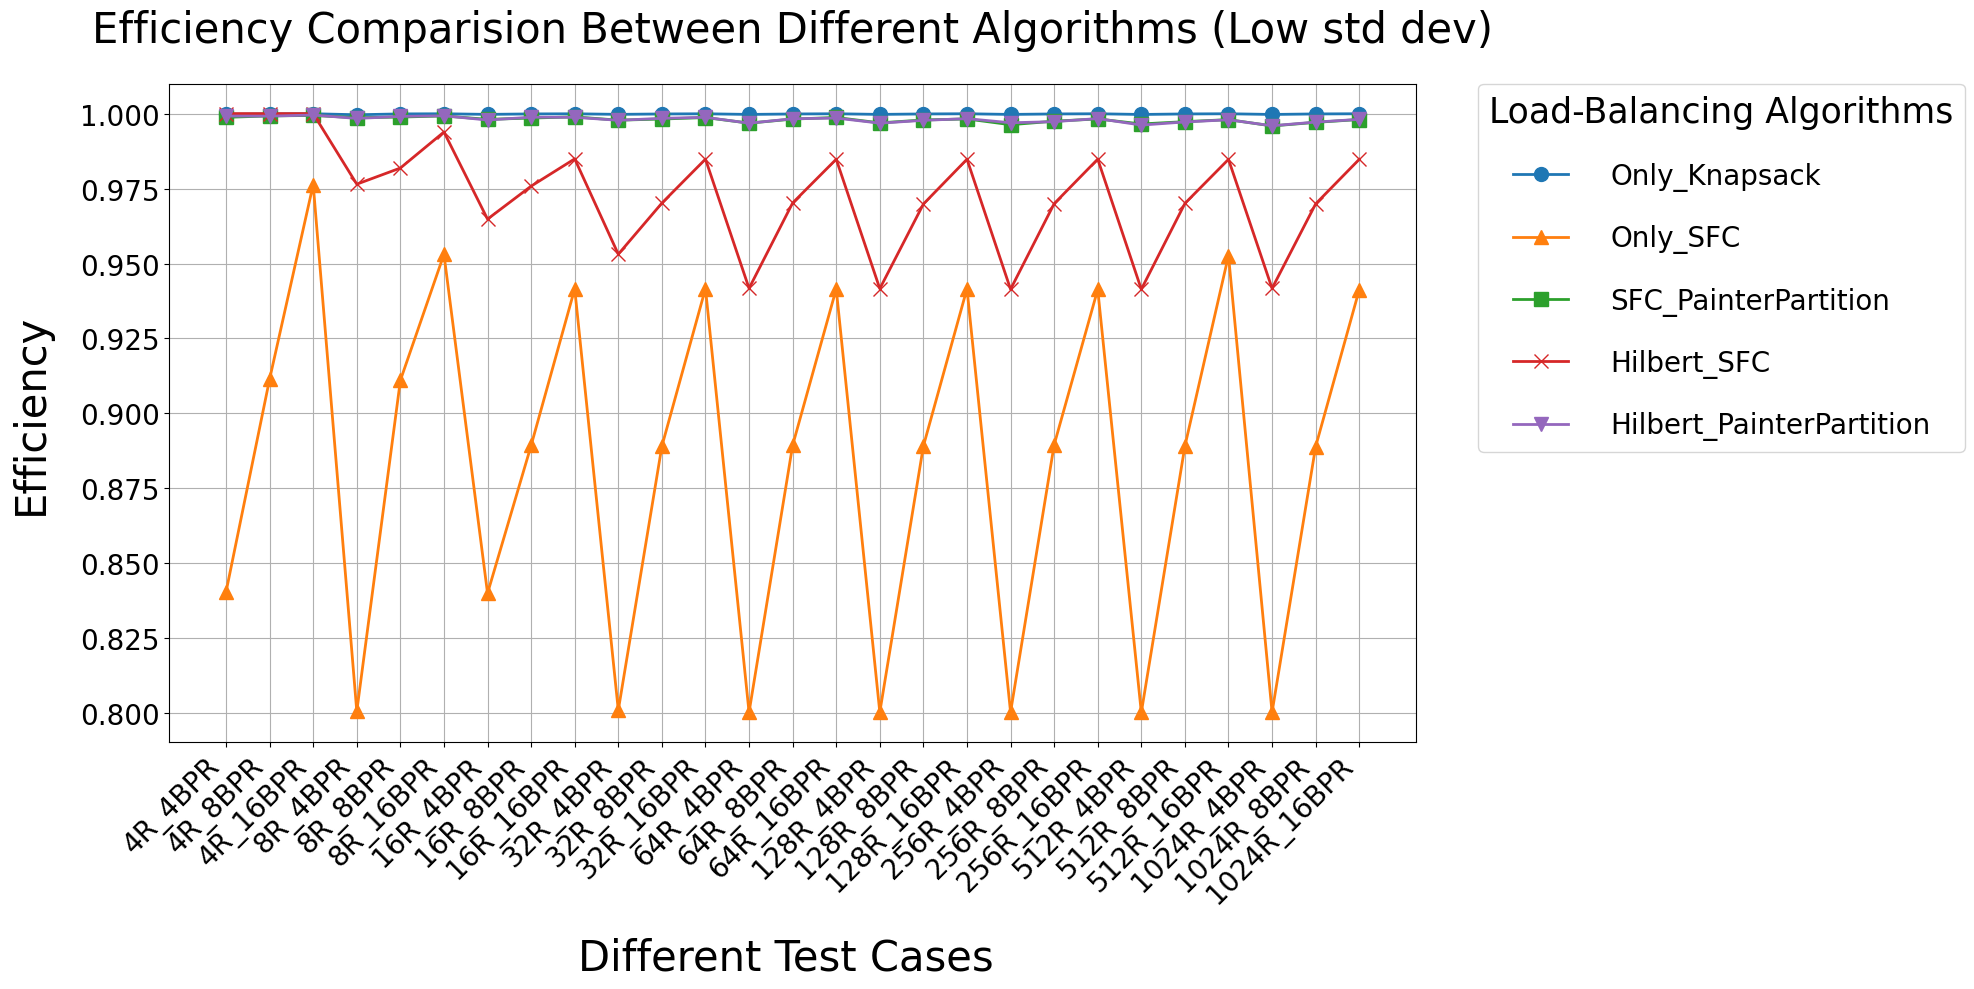

In [43]:
algorithms = [
    ('Only_Knapsack', 'Only_Knapsack_Efficiency_mean', 'Only_Knapsack_Final_Time_mean', 'o'),
    ('Only_SFC', 'Only_SFC_Efficiency_mean', 'Only_SFC_Final_Time_mean', '^'),
    ('SFC_PainterPartition', 'SFC_PainterPartition_Efficiency_mean', 'SFC_PainterPartition_Final_Time_mean', 's'),
    # ('Painter_Knapsack_Combined', 'Painter_Knapsack_Combined_Efficiency_mean', 'Painter_Knapsack_Combined_Final_Time_mean', '*'),
    # ('SFC_Knapsack_Combined', 'SFC_Knapsack_Combined_Efficiency_mean', 'SFC_Knapsack_Combined_Final_Time_mean', 'D'),
    ('Hilbert_SFC', 'Hilbert_SFC_Efficiency_mean', 'Hilbert_SFC_Final_Time_mean', 'x'),
    ('Hilbert_PainterPartition', 'Hilbert_PainterPartition_Efficiency_mean', 'Hilbert_PainterPartition_Final_Time_mean', 'v')
]

x = np.arange(len(new_df['File']))
fig, ax = plt.subplots(figsize=(20, 10))

for alg_name, eff_col, time_col, marker in algorithms:
    ax.plot(x, new_df[eff_col], marker=marker, markersize=10, linewidth=2, label=alg_name)
ax.set_xticks(x)
ax.set_xticklabels(new_df['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases ', fontsize=30,labelpad=20)
ax.set_ylabel('Efficiency', fontsize=30,  labelpad=20)
ax.set_title('Efficiency Comparision Between Different Algorithms (Low std dev)', pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)

ax.legend(title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20,
          bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., labelspacing=1.2, handletextpad=1.5)
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
# plt.savefig('../result/new_result/result_best/efficiency.png', dpi=600)
plt.show()





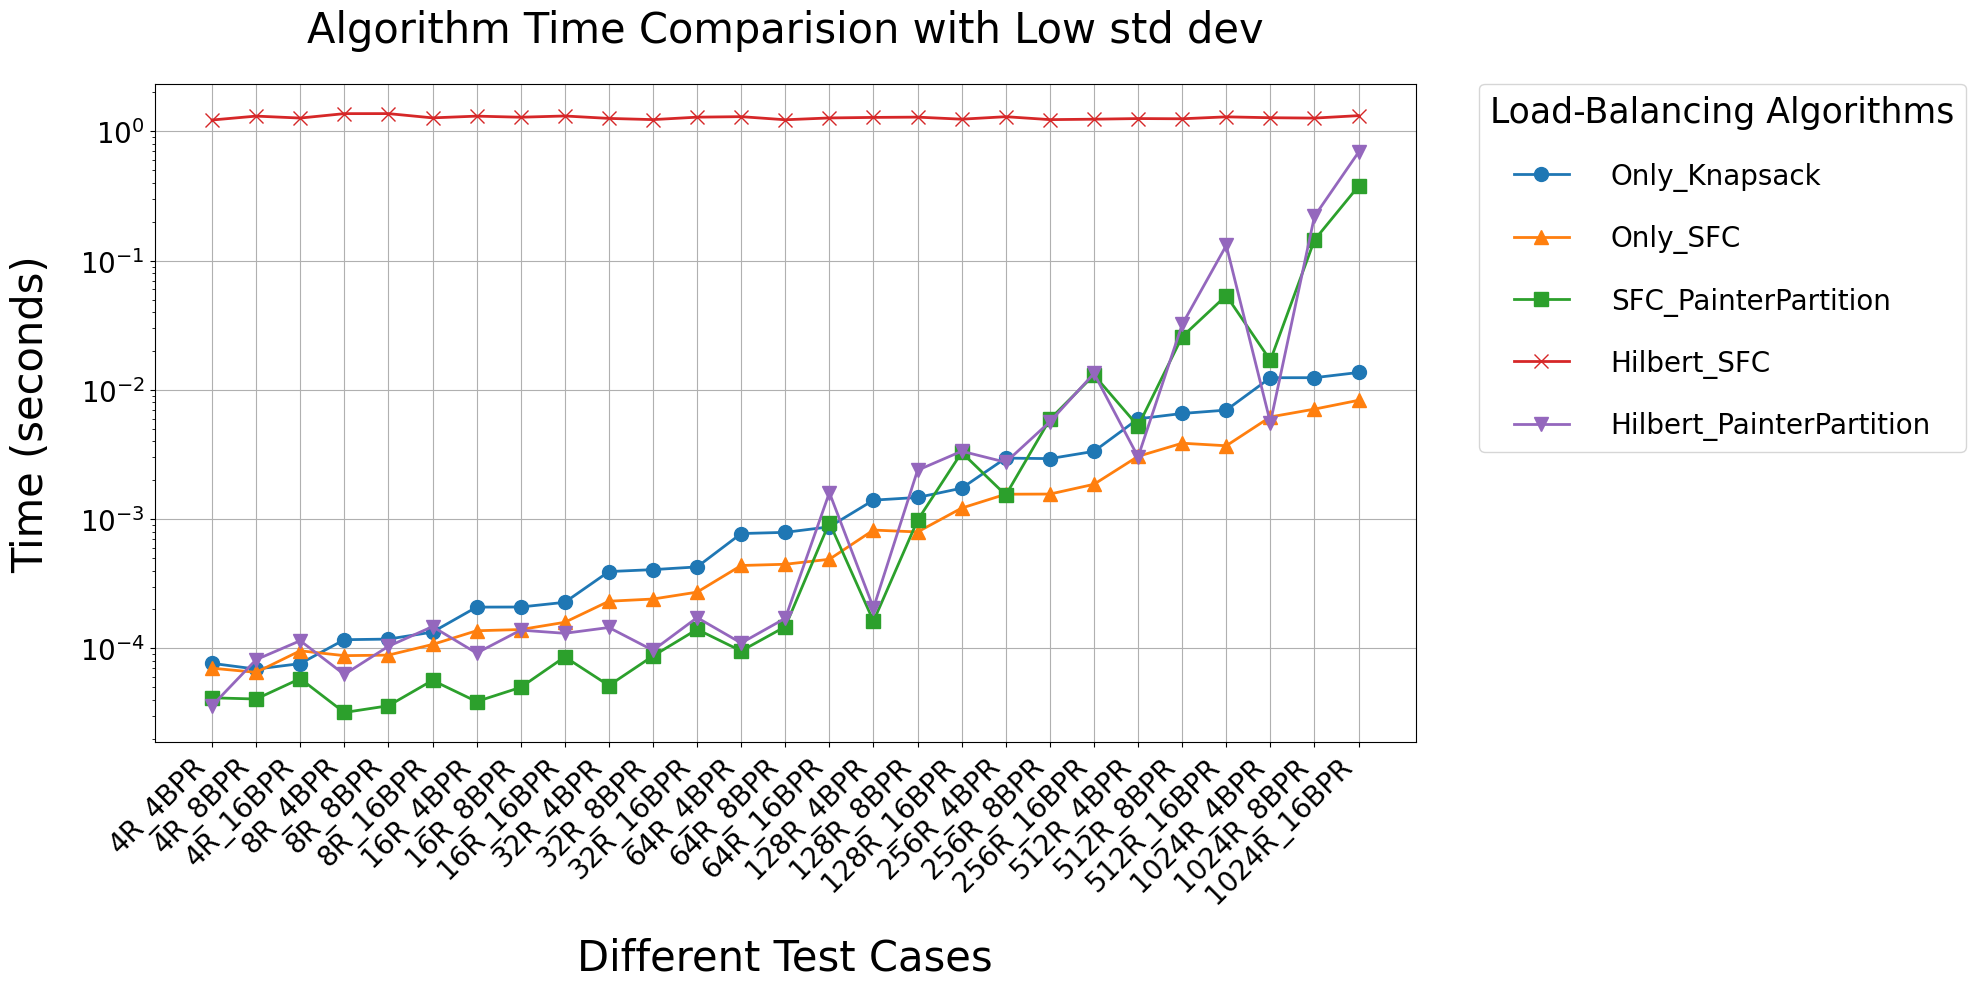

In [44]:
# fig, ax = plt.subplots(figsize=(20, 10))

# for alg_name, eff_col, time_col, marker in algorithms:
#     ax.plot(x, new_df[time_col], marker=marker, markersize=10, linewidth=2, label=alg_name)
# ax.set_xticks(x)
# ax.set_xticklabels(new_df['File'], rotation=45, ha='right')
# ax.set_xlabel('File', fontsize=15)
# ax.set_ylabel('Time (seconds)', fontsize=15)
# ax.set_title('Time Means by File and Algorithm', fontsize=20)
# ax.tick_params(axis='both', which='major', labelsize=15)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)

# plt.tight_layout()
# plt.show()


x = np.arange(len(new_df['File']))
fig, ax = plt.subplots(figsize=(20, 10))

for alg_name, eff_col, time_col, marker in algorithms:
    ax.plot(x, new_df[time_col], marker=marker, markersize=10, linewidth=2, label=alg_name)
ax.set_xticks(x)
ax.set_xticklabels(new_df['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases', fontsize=30,labelpad=20)
ax.set_ylabel('Time (seconds)',  fontsize=30,  labelpad=20)
ax.set_title('Algorithm Time Comparision with Low std dev', pad=30, fontsize=30)
ax.tick_params(axis='both', which='major', labelsize=20)


ax.legend(title='Load-Balancing Algorithms', title_fontsize=25, fontsize=20,
          bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., labelspacing=1.2, handletextpad=1.5)
ax.grid(True)
ax.set_axisbelow(True)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('../result/result_best/time.png', dpi=600)
plt.show()




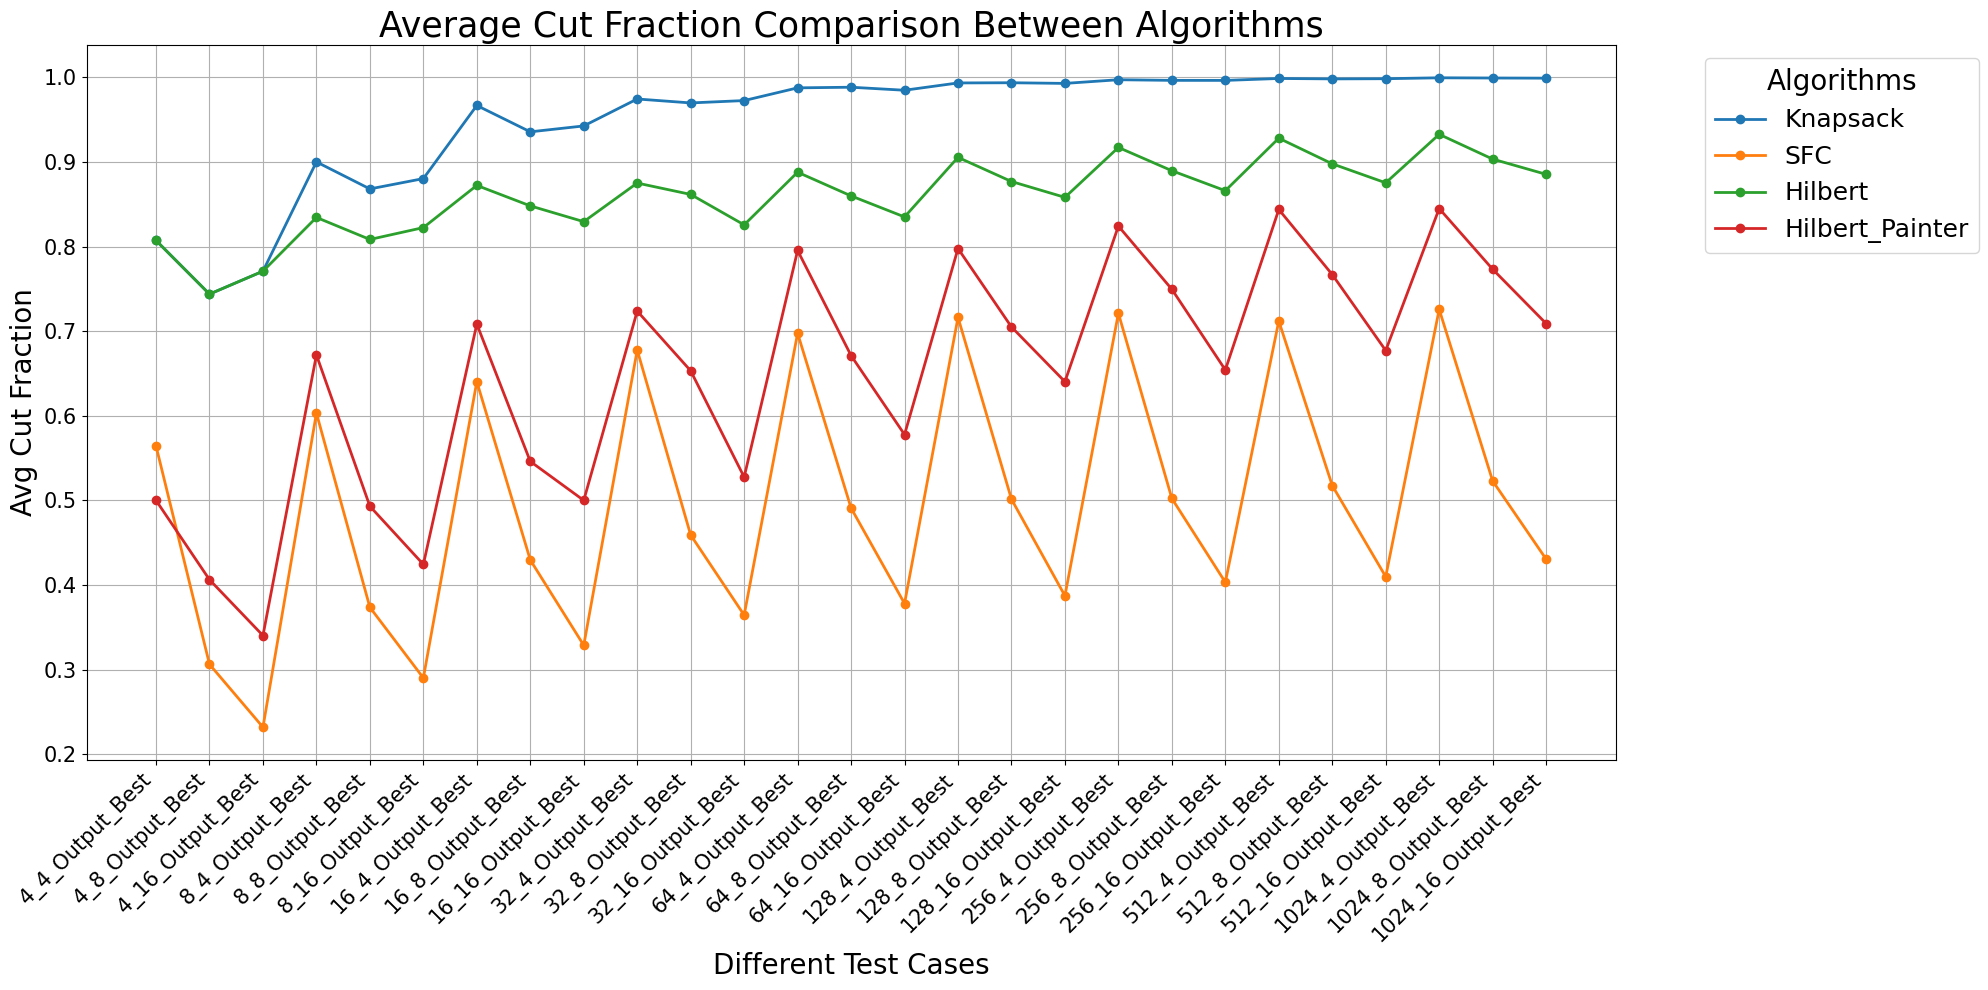

In [45]:
# Extract averaged cut fractions from output files and plot them

def extract_avg_cut_fractions(file_list):
    cut_fraction_patterns = {
        'Knapsack': r'Knapsack - Avg Efficiency: [\d.]+, Avg Cut Fraction: ([\d.]+)',
        'SFC': r'SFC - Avg Efficiency: [\d.]+, Avg Cut Fraction: ([\d.]+)',
        'Hilbert': r'Hilbert - Avg Efficiency: [\d.]+, Avg Cut Fraction: ([\d.]+)',
        'Hilbert_Painter': r'Hilbert \+ Painter - Avg Efficiency: [\d.]+, Avg Cut Fraction: ([\d.]+)'
    }
    data = []
    for file_path in file_list:
        with open(file_path, 'r') as f:
            content = f.read()
        row = {'File': os.path.splitext(os.path.basename(file_path))[0]}
        for key, pattern in cut_fraction_patterns.items():
            match = re.search(pattern, content)
            row[key] = float(match.group(1)) if match else None
        data.append(row)
    return pd.DataFrame(data)

cut_fraction_df = extract_avg_cut_fractions(file_paths)
cut_fraction_df['File'] = cut_fraction_df['File'].apply(lambda x: '_'.join([word.capitalize() for word in x.split('_')]))

algorithms_cf = ['Knapsack', 'SFC', 'Hilbert', 'Hilbert_Painter']
x_cf = np.arange(len(cut_fraction_df['File']))

fig, ax = plt.subplots(figsize=(20, 10))
for alg in algorithms_cf:
    ax.plot(x_cf, cut_fraction_df[alg], marker='o', linewidth=2, label=alg)
ax.set_xticks(x_cf)
ax.set_xticklabels(cut_fraction_df['File'], rotation=45, ha='right')
ax.set_xlabel('Different Test Cases', fontsize=20)
ax.set_ylabel('Avg Cut Fraction', fontsize=20)
ax.set_title('Average Cut Fraction Comparison Between Algorithms', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.legend(title='Algorithms', title_fontsize=20, fontsize=18, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

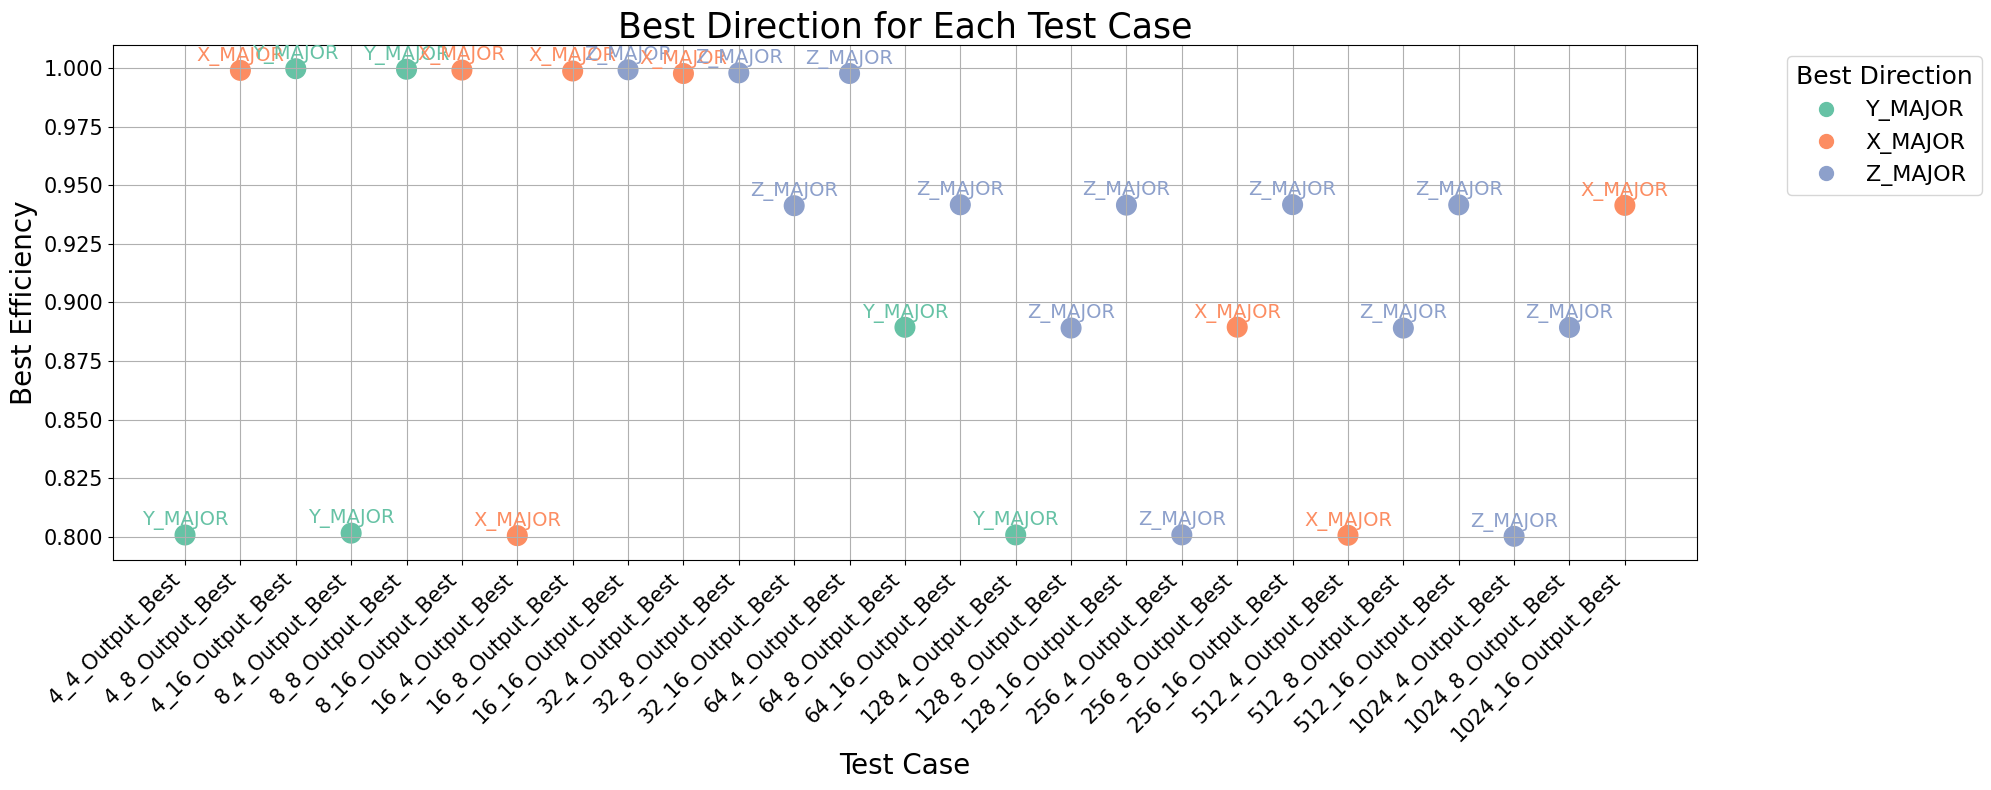

In [55]:
# rename DEFAULT to X_MAJOR for consistency
best_dir_df['Best_Direction'] = best_dir_df['Best_Direction'].replace({'DEFAULT': 'X_MAJOR'})

unique_dirs = best_dir_df['Best_Direction'].unique()
colors = dict(zip(unique_dirs, sns.color_palette('Set2', len(unique_dirs))))
x_dir = np.arange(len(best_dir_df['File']))

fig, ax = plt.subplots(figsize=(20, 8))
scatter = ax.scatter(
    x_dir, best_dir_df['Best_Efficiency'],
    c=best_dir_df['Best_Direction'].map(colors),
    s=200
)

for i, direction in enumerate(best_dir_df['Best_Direction']):
    ax.text(x_dir[i], best_dir_df['Best_Efficiency'][i]+0.002, direction, 
            ha='center', va='bottom', fontsize=14, color=colors.get(direction, 'black'))

ax.set_xticks(x_dir)
ax.set_xticklabels(best_dir_df['File'], rotation=45, ha='right')
ax.set_xlabel('Test Case', fontsize=20)
ax.set_ylabel('Best Efficiency', fontsize=20)
ax.set_title('Best Direction for Each Test Case', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=15)

legend_handles = [mlines.Line2D([], [], color=clr, marker='o', linestyle='None', markersize=10, label=dir) for dir, clr in colors.items()]
ax.legend(handles=legend_handles, title='Best Direction', title_fontsize=18, fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_481342/2598029303.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(t)


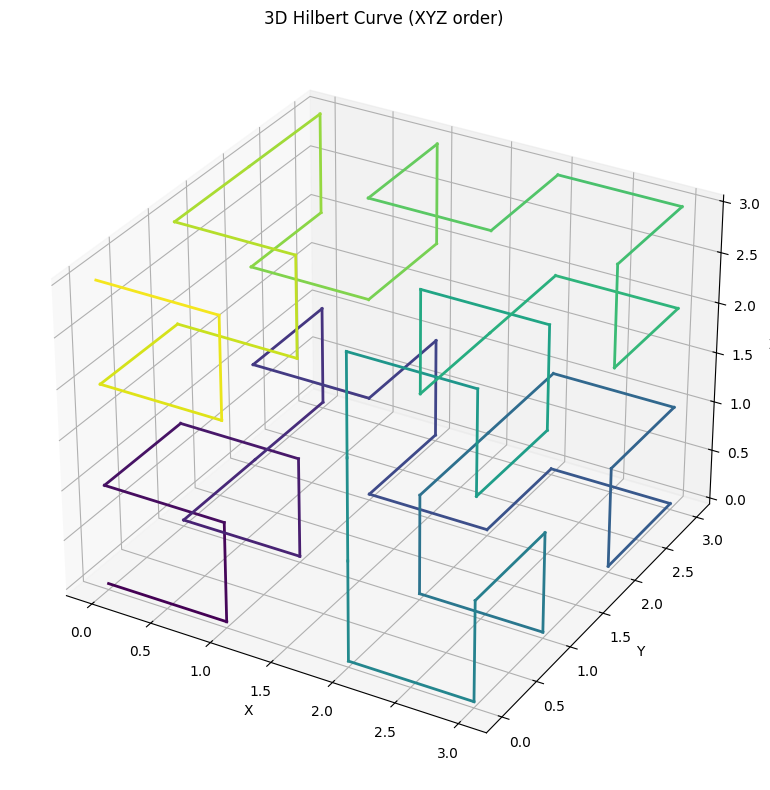

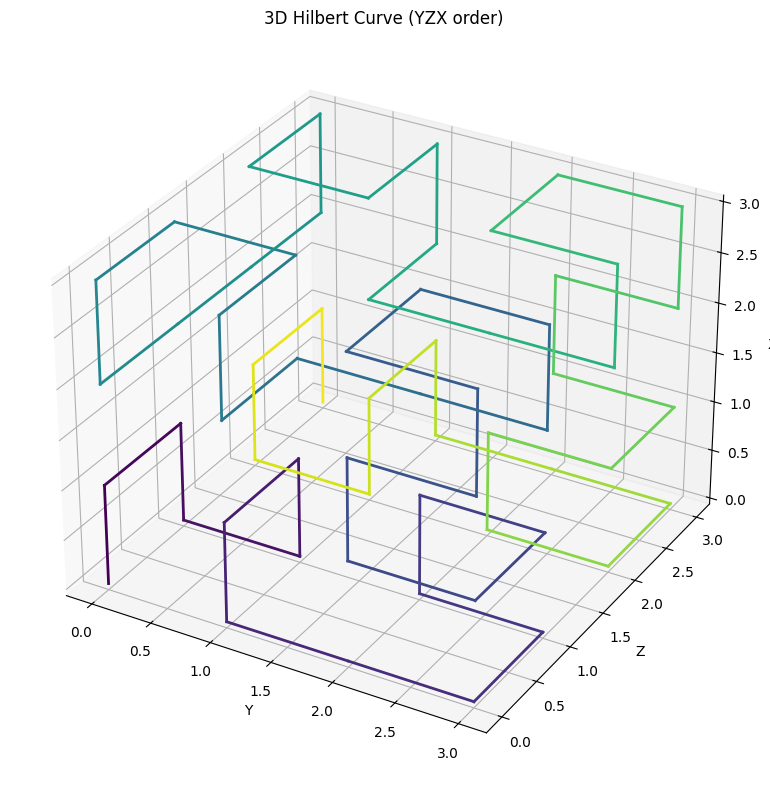

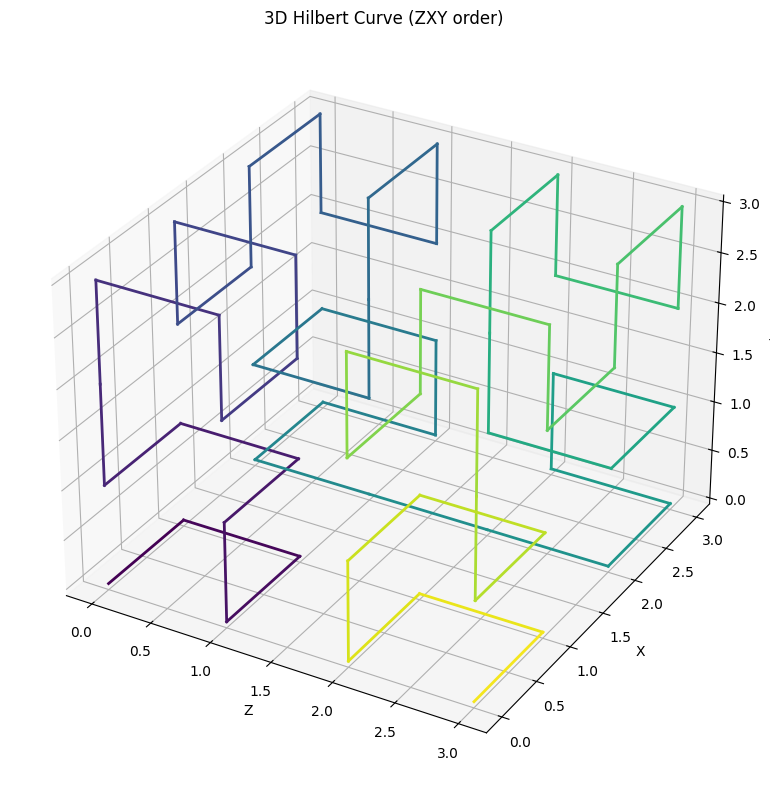

In [5]:
from hilbertcurve.hilbertcurve import HilbertCurve
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt

def plot_hilbert_3d(order=3, axis_order='XYZ', cmap_name='viridis'):
    p = order
    n = 3
    hilbert_curve = HilbertCurve(p, n)
    num_points = 2 ** (p * n // n)
    points = [hilbert_curve.point_from_distance(i) for i in range(num_points)]
    points = np.array(points)
    
    axis_map = {'X': 0, 'Y': 1, 'Z': 2}
    idx = [axis_map[c] for c in axis_order]
    points = points[:, idx]
    
    # Normalize indices for colormap
    t = np.linspace(0, 1, num_points)
    colors = cm.get_cmap(cmap_name)(t)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot with color gradient
    for i in range(num_points - 1):
        ax.plot(
            points[i:i+2, 0], points[i:i+2, 1], points[i:i+2, 2],
            color=colors[i], linewidth=2
        )
    ax.set_title(f'3D Hilbert Curve ({axis_order} order)')
    ax.set_xlabel(f'{axis_order[0]}')
    ax.set_ylabel(f'{axis_order[1]}')
    ax.set_zlabel(f'{axis_order[2]}')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_hilbert_3d(order=6, axis_order='XYZ')
plot_hilbert_3d(order=6, axis_order='YZX')
plot_hilbert_3d(order=6, axis_order='ZXY')


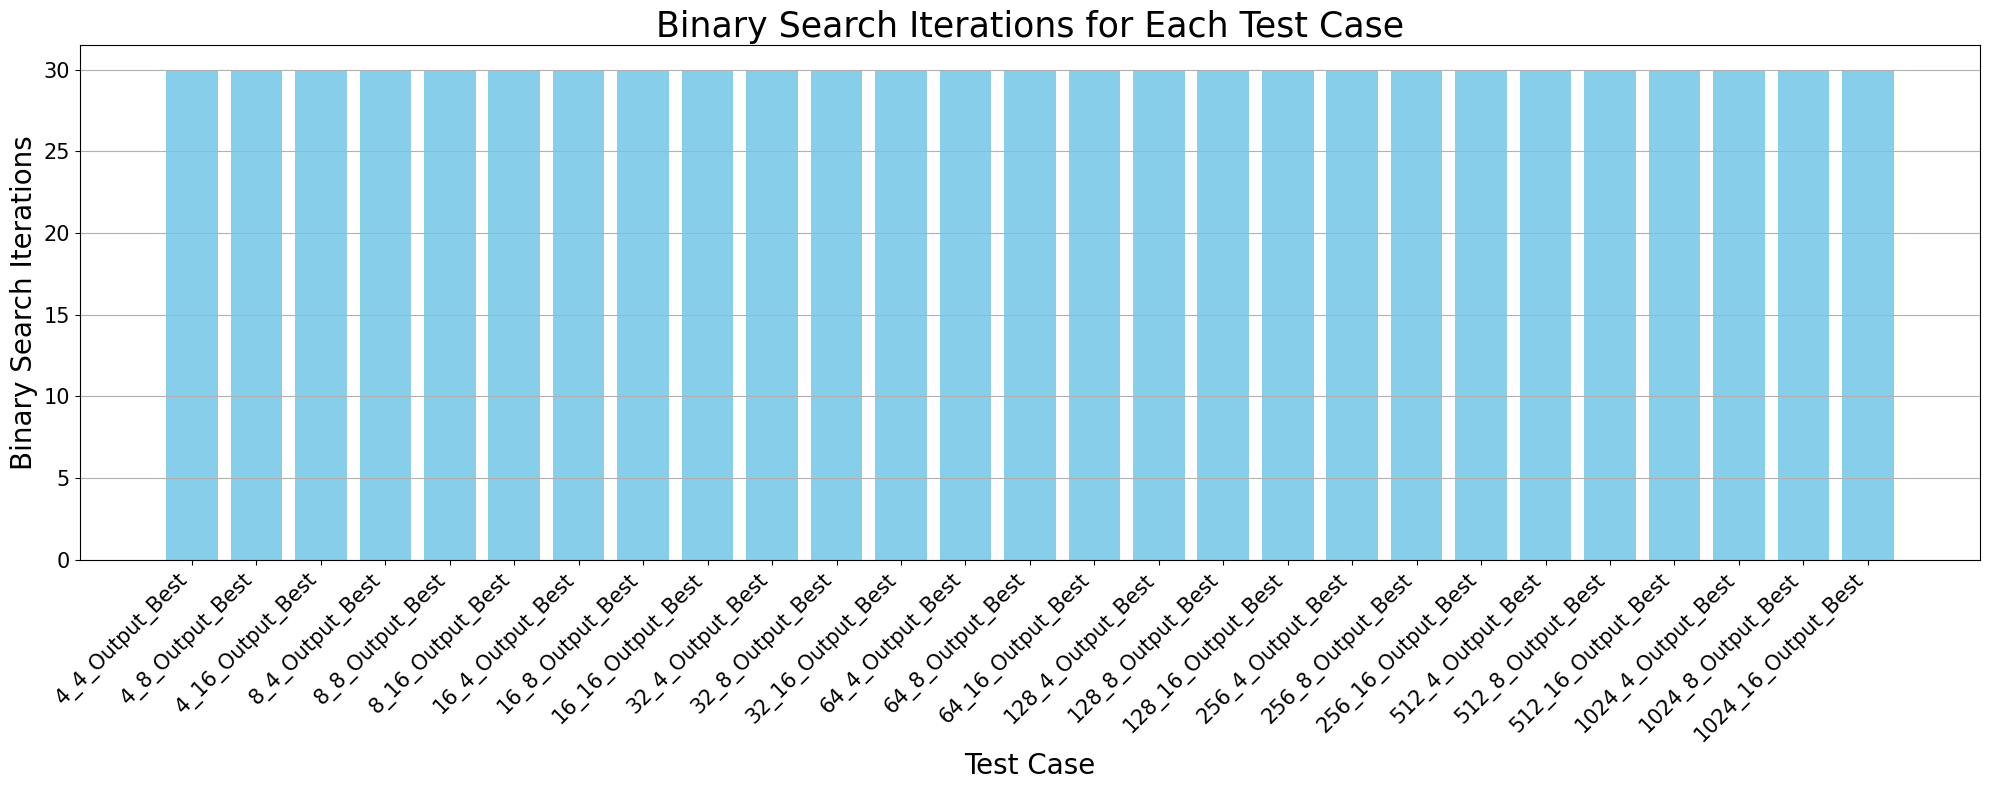

In [57]:
# Extract and plot the number of binary search iterations for each file

def extract_binary_search_iterations(file_list):
    pattern = r"Binary search iterations:\s+(\d+)"
    data = []
    for file_path in file_list:
        with open(file_path, 'r') as f:
            content = f.read()
        match = re.search(pattern, content)
        iterations = int(match.group(1)) if match else None
        row = {'File': os.path.splitext(os.path.basename(file_path))[0], 'Iterations': iterations}
        data.append(row)
    return pd.DataFrame(data)

iterations_df = extract_binary_search_iterations(file_paths)
iterations_df['File'] = iterations_df['File'].apply(lambda x: '_'.join([word.capitalize() for word in x.split('_')]))

x_iter = np.arange(len(iterations_df['File']))

fig, ax = plt.subplots(figsize=(20, 8))
ax.bar(x_iter, iterations_df['Iterations'], color='skyblue')
ax.set_xticks(x_iter)
ax.set_xticklabels(iterations_df['File'], rotation=45, ha='right')
ax.set_xlabel('Test Case', fontsize=20)
ax.set_ylabel('Binary Search Iterations', fontsize=20)
ax.set_title('Binary Search Iterations for Each Test Case', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()